# Модель для прогнозирования оттока клиентов для сервиса доставки кофе

# План работы

**Описание задачи**: 

На рынке доставки кофе высокая конкуренция, поэтому привлечение нового клиента обходится в 5-7 раз дороже, чем удержание существующего. В последние месяцы Happy Beans Coffee столкнулись с проблемой: каждый месяц серзис теряет 10% клиентской базы, что напрямую снижает ежемесячную выручку. Из-за этого также неэффективно расходуется маркетинговый бюджет: он «работает вхолостую», не обеспечивая прироста клиентской базы. Для исправления ситуации необходимо создать проект по прогнозированию оттока клиентов:

**1. Тип:** Задача обучения с учителем;

**2. Целевая переменная (Target):**

`churn` - бинарный признак, где:
- 1 - клиент уйдет (положительный класс, "positive").
- 0 - клиент останется (отрицательный класс, "negative").

**3. Бизнес-кснтекст и цель:**

- Проблема: Ежемесячная потеря 10% клиентской базы, что приводит к прямому снижению выручки и неэффективному расходованию маркетингового бюджета.

- Цель бизнеса: Снизить отток клиентов и оптимизировать маркетинговые расходы за счет своевременного и целенаправленного клиентов, склонных к уходу.
удержания

- Цель ML: Построить модель, которая для каждого клиента в начале месяца рассчитывает вероятность его оттока в течение этого месяца. Это позволит службе удержания клиентов сфокусировать свои усилия и ресурсы (персональные предложения, скидки, опросы) на наиболее "рисковой" группе.

**4. Критерии успешности и метрики качества.**

Учитывая сильный дисбаланс классов, выбор метрик является критически важным.

- Основная метрика: PR-AUC
Обоснование: Precision-Recall AUC (PR-AUC): Это основная метрика для оценки качества модели на несбалансированных данных. Она фокусируется на качестве предсказания положительного класса (уходящих клиентов) и не зависит от доли отрицательного класса, в отличие от ROC-AUC. Цель максимизировать PR-AUC.

- ROC-AUC: Показывает общую способность модели ранжировать клиентов (разделять уходящих и остающихся). Является хорошей дополняющей метрикой, но в условиях сильного дисбаланса может давать излишне оптимистичную оценку Цель - значение выше 0.9.
- Матрица ошибок (Confusion Matrix): Для визуальной интерпретации количества True Positive, False Positive, True Negative и, что самое важное, False Negative.

Отвергаемые метрики.  
- Аccuracy (Точность): Бесполезна в условиях дисбаланса.

**5. Ожидаемый выход модели:** 
- Модель должна возвращать для каждого клиента вероятность принадлежности к классу 1 (вероятнссть оттока). Это позволит не только оинарно классифицировать кпиентов, но и ранжировать их по степени риска.

**Доплнительная информация о данных:**  

**Период агрегации.** Признаки агрегированы за последние 4 недели.  

**Формат данных.** Они представлены в виде готовой аналитической витрины. Для каждого клиента уже рассчитаны и собраны в одну строку все необходимые для моделирования признаки.  

**Структура.** Каждая строка — это один уникальный клиент. Все признаки уже вычислены и представлены в виде числовых и категориальных значений.  

**Содержание данных**
- `user_id` — идентификатор пользователя.
- `days_since_last_order` — количество дней, прошедших с последнего заказа.
- `order_frequency_month` — среднее число заказов в месяц.
- `order_frequency_week` — среднее число заказов в неделю.
- `avg_order_value` — средний чек, в рублях.
- `median_order_value` — медианный чек, в рублях.
- `total_spent_last_month` — сумма заказов за последний месяц.
- `total_spent_last_week` — сумма заказов за последнюю неделю.
- `discount_usage_rate` — доля заказов со скидкой за последний месяц.
- `last_coffee_type` — сорт кофе, купленный пользователем в последний раз на момент сбора данных.
- `preferred_roast` — предпочитаемый тип обжарки.
- `milk_preference` — предпочитаемый тип молока.
- `seasonal_menu_tried` — отметка о том, пробовал ли пользователь новейшее сезонное меню.
- `coffee_bean_origin` — страна происхождения зерна.
- `last_drink_size` — размер последнего напитка, купленного на момент сбора данных.
- `subscription_status` — тип подписки пользователя.
- `app_opens_per_week` — сколько раз за неделю пользователь в среднем открывал приложение доставки кофе.
- `notifications_enabled` — включены ли у пользователя уведомления.
- `review_rating_last_10` — средняя оценка последних на момент сбора данных десяти заказов клиента.
- `review_rating_last_1` — оценка последнего на момент сбора данных заказа клиента.
- `app_crashes_last_month` — сколько раз приложение зависало за последний месяц.
- `seasons` — текущее время года.
- `days_since_last_promo` — сколько дней прошло с последнего использования акции или промокода.
- `phone_type` — тип устройства, с которого пользователь чаще всего совершал покупки.
- `coffee_preference_change` — менялись ли вкусовые предпочтения пользователя.
- `geo_location` — идентификатор региона пользователя.
- `churn` — перестал ли пользователь пользоваться сервисом.

**Этапы проекта**  
- Подготовка среды и библиотек.
- Исследовательский анализ данных (EDA).
- Предобработка данных.
- Обучение и оценка базовой модели.
- Создание и отбор новых признаков.
- Подбор гиперпараметров модели.
- Финальное обучение модели и подготовка артефактов.

## Подготовка среды и библиотек
1. Устанавливаем и настраиваем библиотеки. Для воспроизводимости результатов фиксируем версии пакетов в файле `requirements.txt`.

2. Фиксируем `random_state`.

3. Загружаем данные из CSV-файла. Путь к файлу: `'/datasets/coffee_churn_dataset.csv'`. 

In [1]:
!pip install phik -q
!pip install category_encoders -q

# Импортируем нужные библиотеки
import numpy as np
import pandas as pd
import seaborn as sns
import warnings
import matplotlib.pyplot as plt
import joblib
from sklearn.model_selection import GridSearchCV
from category_encoders import TargetEncoder
from phik import phik_matrix
from sklearn.model_selection import StratifiedKFold, train_test_split, cross_validate
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss, average_precision_score, make_scorer, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import SelectFromModel

# Фиксируем random_state
RANDOM_STATE = 42

In [2]:
#Загружаем данные
data = pd.read_csv( 'https://code.s3.yandex.net/datasets/coffee_churn_dataset.csv',
    sep=',',
    decimal='.'
)

## Первичный анализ данных

### Описание данных

Изучаем данные: выводим первые 10 строк и статистику методом info()

In [3]:
#Выводим первые 10 строк датасета
data.head(10)

,user_id,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,last_coffee_type,...,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,seasons,days_since_last_promo,phone_type,coffee_preference_change,geo_location,churn
0,user_00318,0.0,12.942519,NaN,316.833872,260.645090,3089.991009,NaN,0.337031,blend,...,1.0,5.176792,3.302238,NaN,summer,6.0,android,0.0,geo_75,1
1,user_07234,2.0,1.569146,0.214494,780.135158,540.597850,998.380941,107.369409,0.547659,arabica,...,1.0,4.392991,NaN,0.0,autumn,16.0,ios,0.0,geo_95,0
2,user_04816,11.0,2.996666,0.771864,682.636256,471.494559,1328.140204,392.600011,0.120258,arabica,...,1.0,4.977712,4.379219,0.0,spring,11.0,web,1.0,geo_25,0
3,user_04419,0.0,4.299255,1.210480,2115.487425,708.529812,2999.628366,1084.352054,NaN,robusta,...,1.0,3.712526,3.043618,0.0,summer,3.0,android,0.0,geo_2,0
4,user_09698,3.0,7.249864,1.761027,3519.602170,1199.372894,8377.729478,2551.775211,0.074990,robusta,...,0.0,4.528271,5.642993,1.0,winter,14.0,ios,0.0,geo_19,1
5,user_01247,0.0,1.284824,0.418197,1092.164843,338.082043,471.825472,159.366225,0.350490,arabica,...,0.0,4.235214,4.835587,1.0,winter,17.0,android,0.0,geo_68,0
6,user_08887,5.0,6.124180,1.214905,428.486273,174.449445,1088.359993,254.120345,0.146130,robusta,...,NaN,4.406612,4.144391,0.0,spring,9.0,android,0.0,geo_3,0
7,user_01885,3.0,4.640247,1.029297,27.368788,9.812365,NaN,10.523663,0.173646,robusta,...,1.0,4.793547,4.321319,3.0,NaN,12.0,android,0.0,geo_3,1
8,user_03703,9.0,3.303446,NaN,1886.543949,964.629212,3312.557597,748.655191,0.676576,blend,...,1.0,4.405572,NaN,0.0,spring,5.0,android,0.0,geo_45,0
9,user_01536,0.0,0.310724,-0.094052,607.847810,NaN,151.508968,-41.895977,NaN,blend,...,1.0,4.362385,2.624536,2.0,autumn,14.0,ios,0.0,geo_2,0


In [4]:
#Выводим информацию о датасете
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10450 entries, 0 to 10449
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   user_id                   10450 non-null  object 
 1   days_since_last_order     9505 non-null   float64
 2   order_frequency_month     9850 non-null   float64
 3   order_frequency_week      10062 non-null  float64
 4   avg_order_value           9867 non-null   float64
 5   median_order_value        9619 non-null   float64
 6   total_spent_last_month    10156 non-null  float64
 7   total_spent_last_week     9506 non-null   float64
 8   discount_usage_rate       10053 non-null  float64
 9   last_coffee_type          10192 non-null  object 
 10  preferred_roast           10334 non-null  object 
 11  milk_preference           9782 non-null   object 
 12  seasonal_menu_tried       9461 non-null   float64
 13  coffee_bean_origin        9768 non-null   object 
 14  last_d

In [5]:
#Выводим статистику по полям
display(data.describe())

,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,seasonal_menu_tried,app_opens_per_week,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,days_since_last_promo,coffee_preference_change,churn
count,9505.000000,9850.000000,10062.000000,9867.000000,9619.000000,10156.000000,9506.000000,10053.000000,9461.000000,9554.000000,9913.000000,9757.000000,9593.000000,9729.000000,9719.000000,9840.000000,10450.000000
mean,4.394214,4.025666,0.930686,1063.741207,452.651500,1946.132979,413.004760,0.284446,0.701194,11.330895,0.753052,4.206709,4.022460,1.013362,14.554584,0.192480,0.060191
std,4.858757,2.826144,0.657261,707.713396,258.657571,2370.619590,445.634902,0.158735,0.457759,14.528887,0.431258,0.782212,1.207883,1.010342,15.308869,0.394268,0.237852
min,0.000000,0.011046,-0.169131,-32.075932,-10.353340,-43.716463,-2290.559468,0.002162,0.000000,0.000000,0.000000,1.415526,-0.897000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,1.937767,0.445185,552.898663,262.908598,629.680382,136.565833,0.159884,0.000000,6.313628,1.000000,3.675543,3.214157,0.000000,4.000000,0.000000,0.000000
50%,3.000000,3.381094,0.784839,898.643524,406.456818,1300.409757,288.277327,0.264583,1.000000,9.228383,1.000000,4.203555,3.990032,1.000000,10.000000,0.000000,0.000000
75%,6.000000,5.439363,1.262350,1406.332153,590.418070,2481.650495,549.699420,0.387056,1.000000,12.726649,1.000000,4.717292,4.845225,2.000000,20.000000,0.000000,0.000000
max,40.000000,27.389318,6.302624,5901.965278,2189.101644,79298.849570,8615.988952,0.887301,1.000000,224.587876,1.000000,7.384425,8.558443,7.000000,140.000000,1.000000,1.000000


In [6]:
#Делаем копию датасета
temp = data.copy()

**Промежуточный вывод о предоставленных данных**

Данные за последние 4 недели представлены таблицей размером 10450х27. Данные соответствуют заявленным, тип данных корректен: 16 полей типа `float`, 10 полей типа `object` и 1 поле `churn` с целевой переменной, представленной в виде бинарной классификации (1 - человек ушёл, 0 - человек остался).  При этом практических во всех полях имеются пропущенные значения. Имеются аномалии: отрицательные значения(например -2290 в значении среднего количества кофе) и необъяснимо большие. 

### Изучение целевой переменной

Целевая переменная в столбце `churn` представлена в виде ответа на вопрос: "Остался ли человек пользователем (0) или ушёл (1). Данные в этом поле не содежат пропуски, значит для каждого пользователя есть точная информация о его лояльности, исключения могут составить лишь ошибки в данных (Например любое другое число кроме 1 или 0). Для более точного понимания необходимо проанализировать распределения этой переменной.

Распределение пользователей по оттоку:
----------------------------------------
          Количество пользователей  Процент от общего числа
Остались                      9821                    93.98
Ушли                           629                     6.02


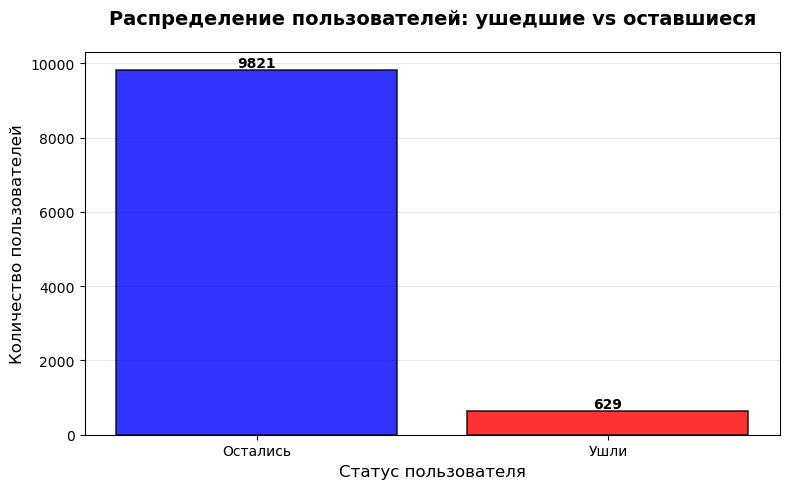

In [7]:
churn_counts = data['churn'].value_counts()
churn_percentages = data['churn'].value_counts(normalize=True) * 100

churn_summary = pd.DataFrame({
    'Количество пользователей': churn_counts,
    'Процент от общего числа': churn_percentages.round(2)
})

churn_summary.index = ['Остались', 'Ушли']

print("Распределение пользователей по оттоку:")
print("-" * 40)
print(churn_summary)

fig, ax = plt.subplots(figsize=(8, 5))

churn_data = data['churn'].value_counts()
labels = ['Остались', 'Ушли']
colors = ['blue', 'red']  

bars = ax.bar(labels, churn_data.values, color=colors, alpha=0.8, edgecolor='black', linewidth=1.2)

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 10,
              f'{height}', ha='center', va='bottom', fontweight='bold')

ax.set_title('Распределение пользователей: ушедшие vs оставшиеся', fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Статус пользователя', fontsize=12)
ax.set_ylabel('Количество пользователей', fontsize=12)
ax.grid(axis='y', alpha=0.3)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

**Промежуточный вывод по целевой переменной**

По таблице видно, что количество ушедших клиентов составляет всего 6% от общего числа. Поэтому при делении данных на выборки будем использовать стратификацию для сбалансированного соотношения классов целевой переменной. Основная метрика: PR-AUC Обоснование: Precision-Recall AUC (PR-AUC): Это основная метрика для оценки качества модели на несбалансированных данных. Она фокусируется на качестве предсказания положительного класса (уходящих клиентов) и не зависит от доли отрицательного класса, в отличие от ROC-AUC.

### Проверка на дубликаты

Проверяем данные на наличие дубликатов.

In [8]:
dup_sum = data.duplicated().sum()
print('Количество явных дубликатов:', dup_sum)

dup_id = data.duplicated(subset=['user_id']).sum()
print('Количество задублированных строк по идентификатору пользователя:', dup_id)

Количество явных дубликатов: 0
Количество задублированных строк по идентификатору пользователя: 0


### Обработка пропусков

In [9]:
#Формируем таблицу с информацией о пропущенных значениях
table_nan = pd.DataFrame({
    'Количество пропусков': data.isnull().sum(),
    'Процент пропусков, %' : (data.isnull().sum() / len(data) * 100).round(2),
    'Количество пропусков в классе 1': data [data ['churn'] == 1].isnull().sum(),
    'Доля пропусков (%) в классе 1': (data [data ['churn'] == 1].isnull().sum() / len(data) * 100).round(2)
})

table_nan = table_nan.sort_values('Количество пропусков', ascending=False)
table_nan

,Количество пропусков,"Процент пропусков, %",Количество пропусков в классе 1,Доля пропусков (%) в классе 1
seasonal_menu_tried,989,9.46,45,0.43
days_since_last_order,945,9.04,58,0.56
total_spent_last_week,944,9.03,66,0.63
subscription_status,938,8.98,49,0.47
app_opens_per_week,896,8.57,46,0.44
review_rating_last_1,857,8.20,58,0.56
median_order_value,831,7.95,58,0.56
days_since_last_promo,731,7.00,39,0.37
app_crashes_last_month,721,6.90,38,0.36
review_rating_last_10,693,6.63,37,0.35


Общая картина пропусков

В данных наблюдается значительное количество пропусков — они присутствуют почти во всех признаках, кроме user_id и churn. Наибольшая доля пропусков (9,03–9,46 %) зафиксирована в следующих признаках:

- seasonal_menu_tried (989 пропусков, 9,46 %);

- days_since_last_order (945 пропусков, 9,04 %);

- total_spent_last_week (944 пропуска, 9,03 %);

- subscription_status (938 пропусков, 8,98 %).

Учитывая сильный дисбаланс классов в целевой переменной, пропуски будут обработаны следующем способом:
- Категориальные значения - модой
- Числовые поля - медианой

### Изучаем категориальные значения 

Количество уникальный значений в столбце last_coffee_type
Unique values: ['blend' 'arabica' 'robusta' nan]


last_coffee_type
arabica    6134
robusta    2524
blend      1534
Name: count, dtype: int64

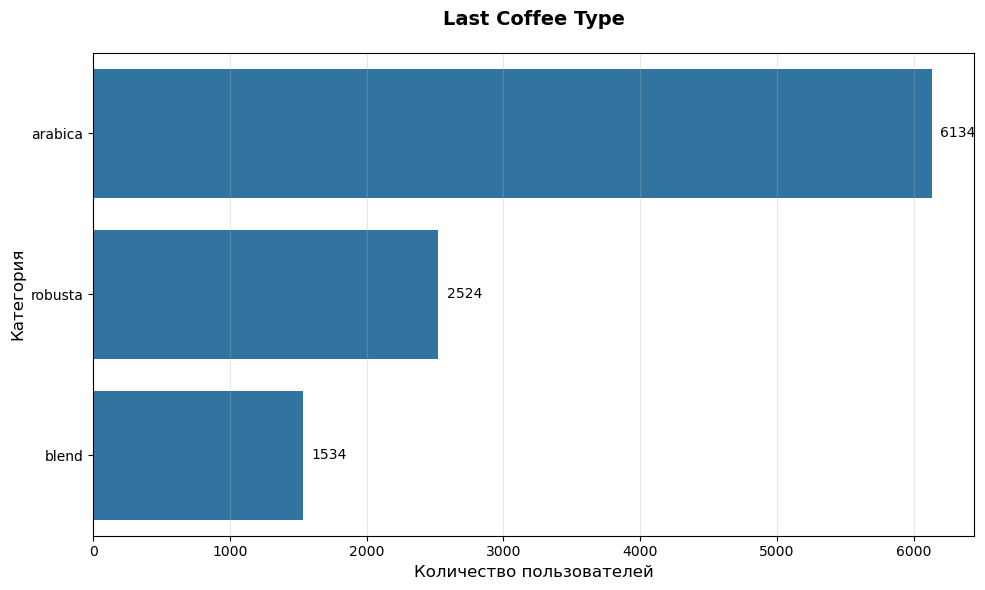

Количество уникальный значений в столбце preferred_roast
Unique values: ['light' 'medium' 'dark' nan]


preferred_roast
medium    3458
light     3453
dark      3423
Name: count, dtype: int64

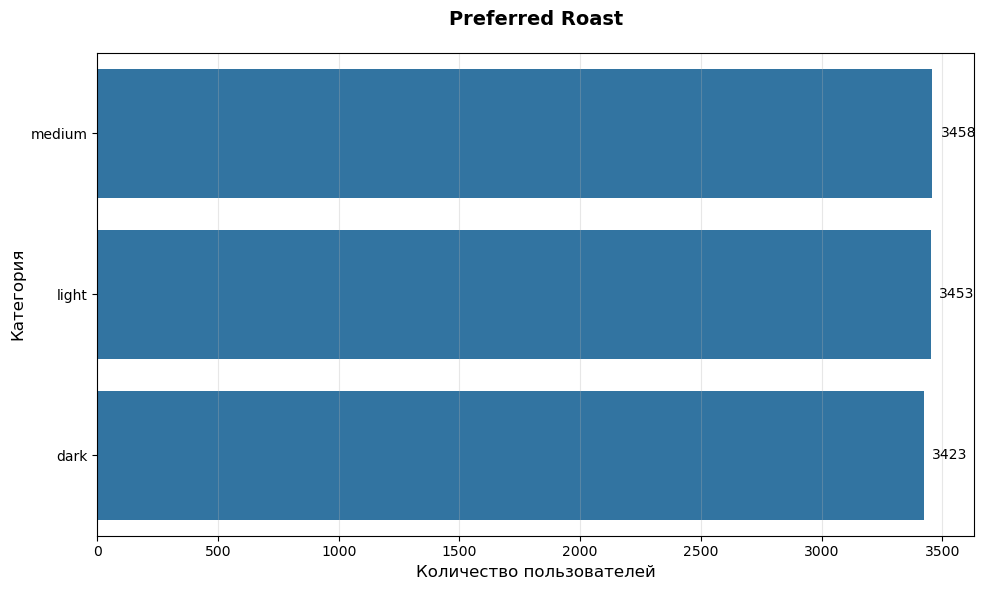

Количество уникальный значений в столбце milk_preference
Unique values: ['almond' 'whole' 'oat' 'skim' 'soy' nan 'none']


milk_preference
whole     2876
oat       1982
almond    1483
skim      1451
none      1015
soy        975
Name: count, dtype: int64

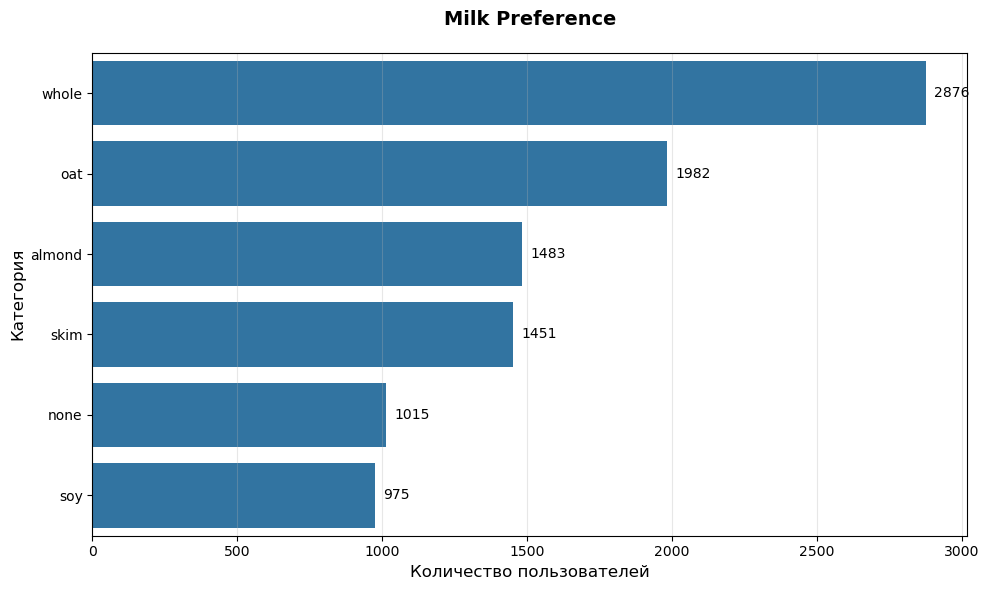

Количество уникальный значений в столбце coffee_bean_origin
Unique values: ['vietnam' 'guatemala' 'brazil' 'colombia' 'kenya' nan 'ethiopia']


coffee_bean_origin
ethiopia     1690
kenya        1646
vietnam      1635
guatemala    1621
brazil       1596
colombia     1580
Name: count, dtype: int64

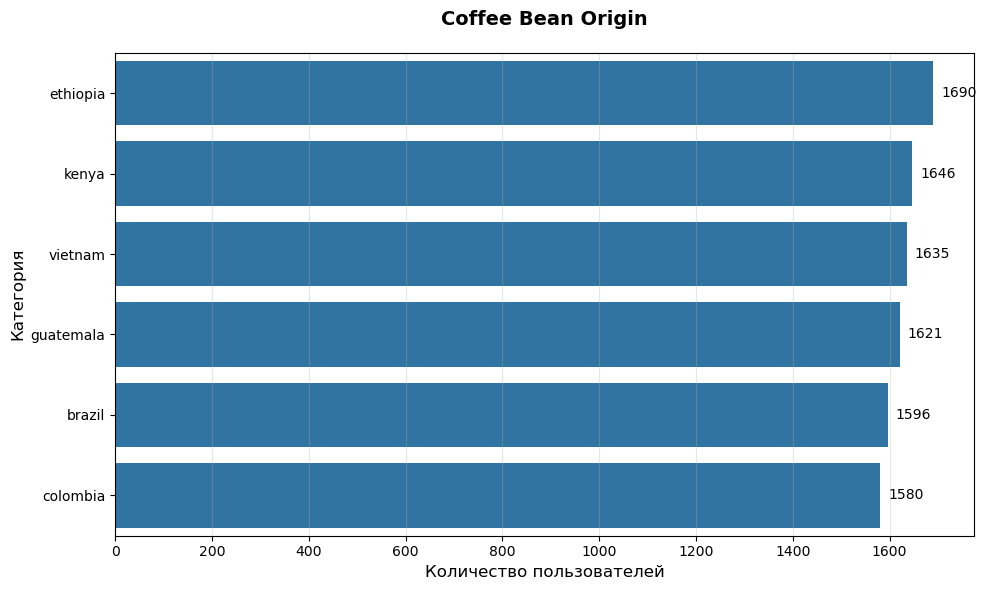

Количество уникальный значений в столбце last_drink_size
Unique values: ['large' 'medium' 'small' nan]


last_drink_size
medium    4925
large     2997
small     2024
Name: count, dtype: int64

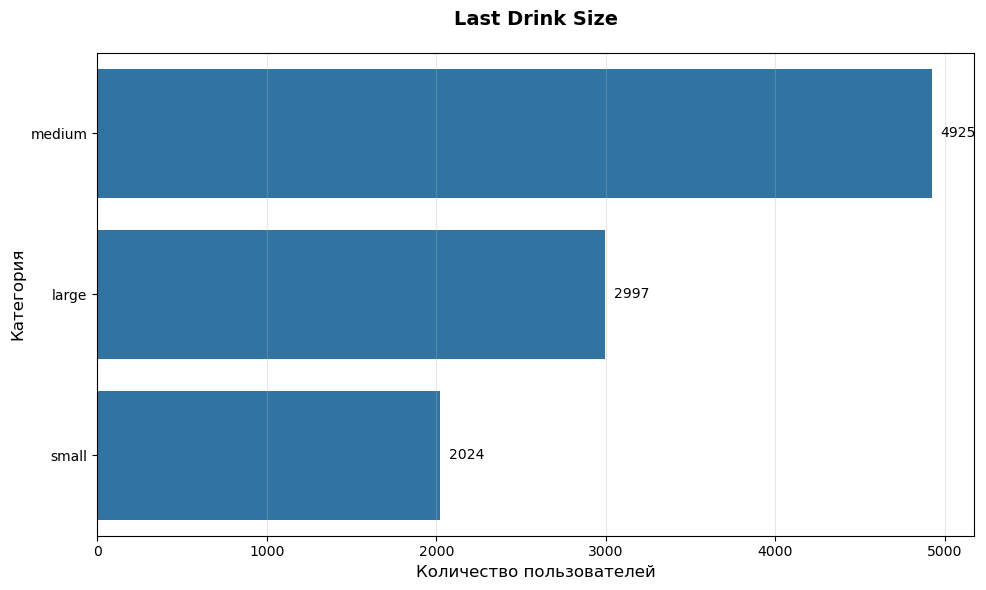

Количество уникальный значений в столбце subscription_status
Unique values: ['pro' 'none' 'premium' 'basic' nan]


subscription_status
none       3803
basic      2862
premium    1923
pro         924
Name: count, dtype: int64

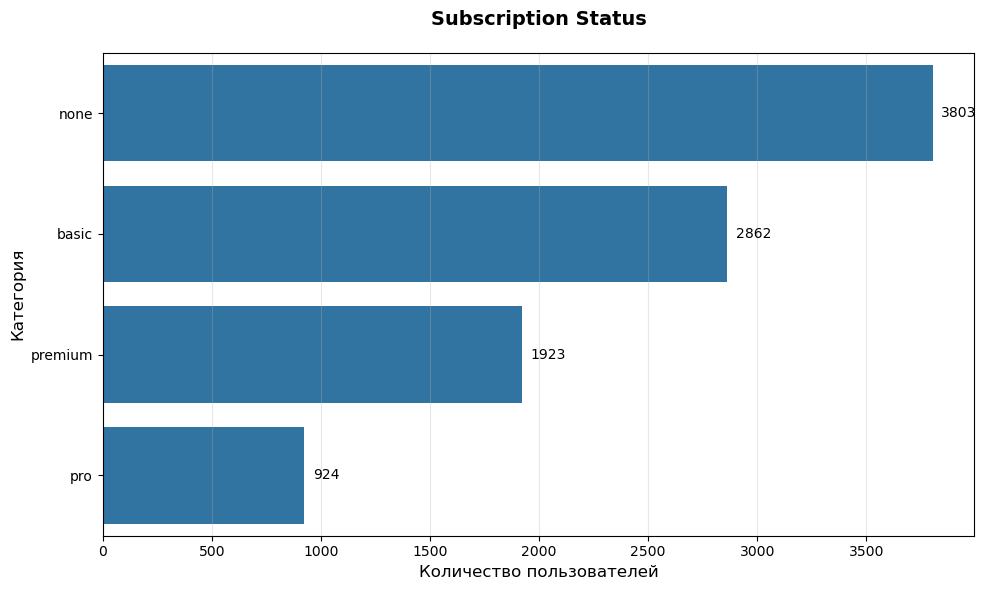

Количество уникальный значений в столбце phone_type
Unique values: ['android' 'ios' 'web' nan]


phone_type
android    4611
ios        4502
web        1001
Name: count, dtype: int64

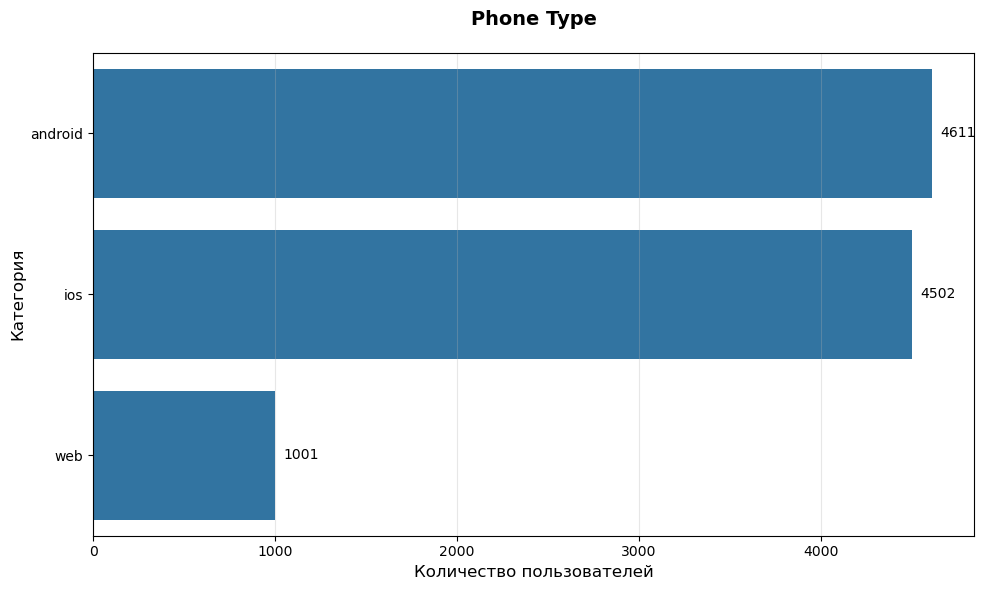

Количество уникальный значений в столбце seasons
Unique values: ['summer' 'autumn' 'spring' 'winter' nan]


seasons
spring    2507
autumn    2433
winter    2423
summer    2408
Name: count, dtype: int64

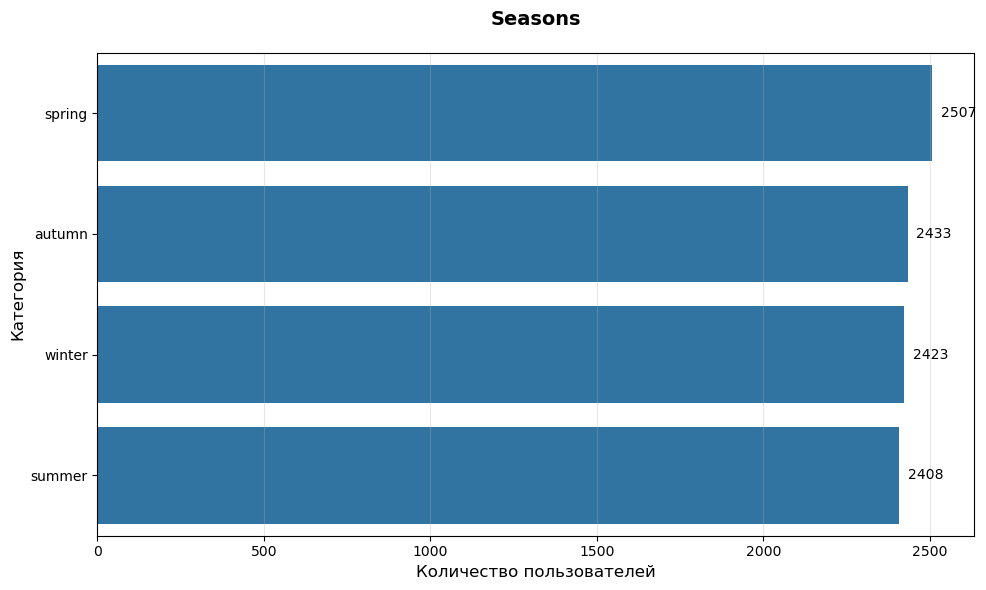

Количество уникальный значений в столбце geo_location
Unique values: ['geo_75' 'geo_95' 'geo_25' 'geo_2' 'geo_19' 'geo_68' 'geo_3' 'geo_45'
 'geo_15' nan 'geo_30' 'geo_93' 'geo_64' 'geo_40' 'geo_87' 'geo_17'
 'geo_11' 'geo_94' 'geo_1' 'geo_50' 'geo_67' 'geo_51' 'geo_97' 'geo_16'
 'geo_78' 'geo_100' 'geo_98' 'geo_43' 'geo_8' 'geo_48' 'geo_61' 'geo_74'
 'geo_35' 'geo_59' 'geo_46' 'geo_5' 'geo_23' 'geo_91' 'geo_42' 'geo_90'
 'geo_4' 'geo_96' 'geo_57' 'geo_71' 'geo_54' 'geo_65' 'geo_32' 'geo_14'
 'geo_72' 'geo_29' 'geo_9' 'geo_83' 'geo_12' 'geo_76' 'geo_92' 'geo_84'
 'geo_31' 'geo_34' 'geo_41' 'geo_18' 'geo_24' 'geo_85' 'geo_49' 'geo_69'
 'geo_47' 'geo_86' 'geo_99' 'geo_36' 'geo_79' 'geo_26' 'geo_73' 'geo_13'
 'geo_10' 'geo_58' 'geo_63' 'geo_82' 'geo_22' 'geo_39' 'geo_81' 'geo_21'
 'geo_27' 'geo_33' 'geo_20' 'geo_60' 'geo_53' 'geo_88' 'geo_62' 'geo_70'
 'geo_28' 'geo_56' 'geo_52' 'geo_66' 'geo_55' 'geo_38' 'geo_89' 'geo_37'
 'geo_80' 'geo_6' 'geo_77' 'geo_44' 'geo_7']


geo_location
geo_2     1629
geo_3     1573
geo_1     1532
geo_99     117
geo_95     110
          ... 
geo_41      42
geo_55      41
geo_45      41
geo_60      40
geo_86      38
Name: count, Length: 100, dtype: int64

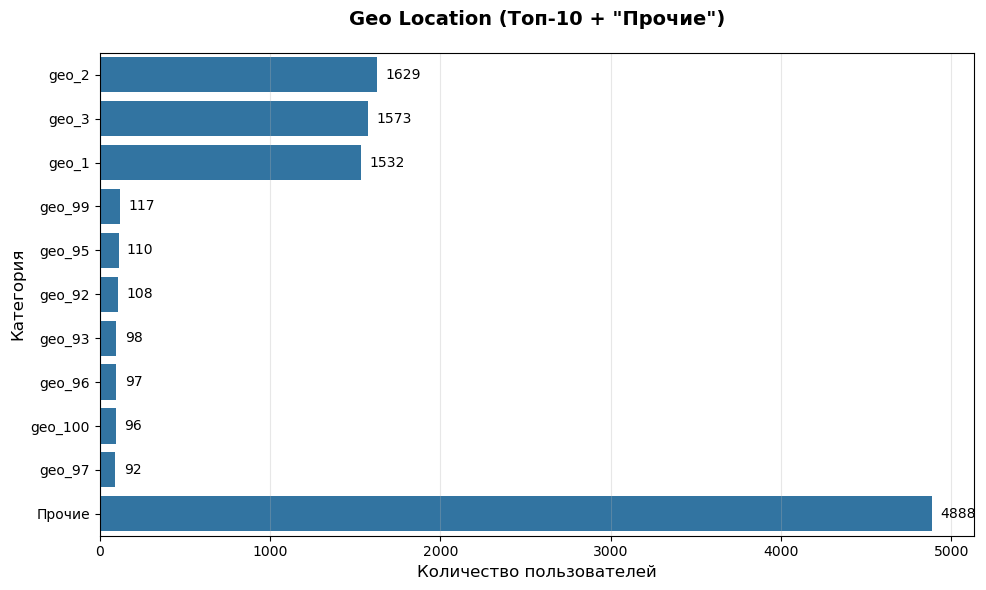

In [10]:
#Создадим список категориальных признаков
cat_columns = ['last_coffee_type', 
               'preferred_roast', 
               'milk_preference', 
               'coffee_bean_origin', 
               'last_drink_size', 
               'subscription_status', 
               'phone_type', 
               'seasons', 
               'geo_location']

for col in cat_columns:
    uniq = data[col].value_counts()
    print('='*70)
    print(f'Количество уникальный значений в столбце {col}')
    print("Unique values:", data[col].unique())
    display(uniq)
    
    
    plt.figure(figsize=(10, 6))
    
    if col == 'geo_location':
        # Для geo_location показываем только топ‑10 значений
        top10 = uniq.nlargest(10)
        others_sum = uniq[~uniq.index.isin(top10.index)].sum()
        if others_sum > 0:
            top10['Прочие'] = others_sum
        plot_data = top10
        title = f'{col} (топ‑10 + "Прочие")'
    else:
        plot_data = uniq
        title = col
    
    # Строим столбчатую диаграмму
    ax = sns.barplot(
        x=plot_data.values,
        y=plot_data.index.astype(str)
    )
    
    # Настройки графика
    plt.title(title.replace('_', ' ').title(), fontsize=14, fontweight='bold', pad=20)
    plt.xlabel('Количество пользователей', fontsize=12)
    plt.ylabel('Категория', fontsize=12)
    
    # Добавляем подписи значений на столбцах
    for i, v in enumerate(plot_data.values):
        ax.text(v + max(plot_data.values) * 0.01, i, str(v),
                  color='black', va='center', fontsize=10)
    
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

**Промежуточный вывод по категориальным признакам**

Для кодирования всех категориальных признаков будем использовать OneHotEncoder


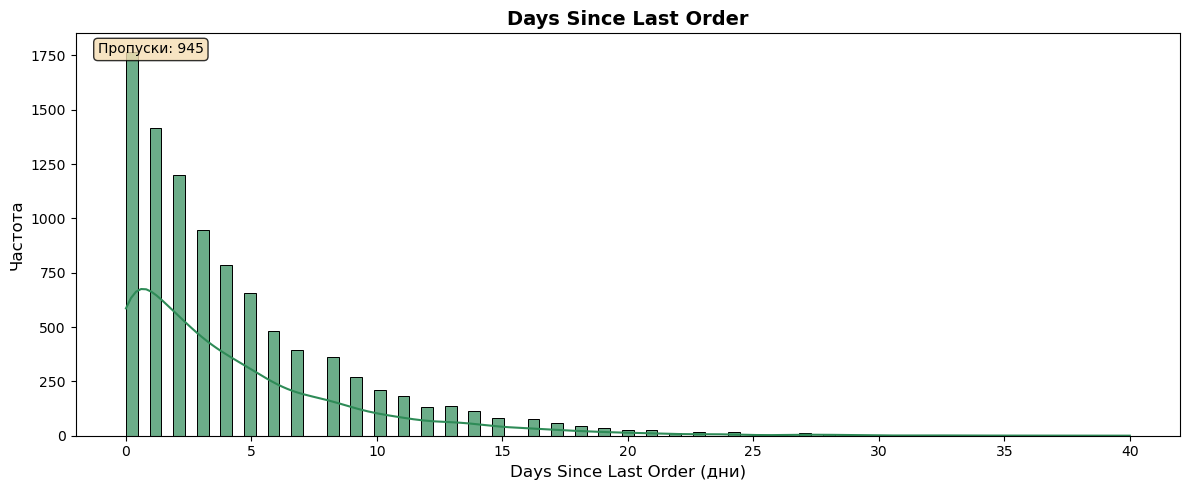

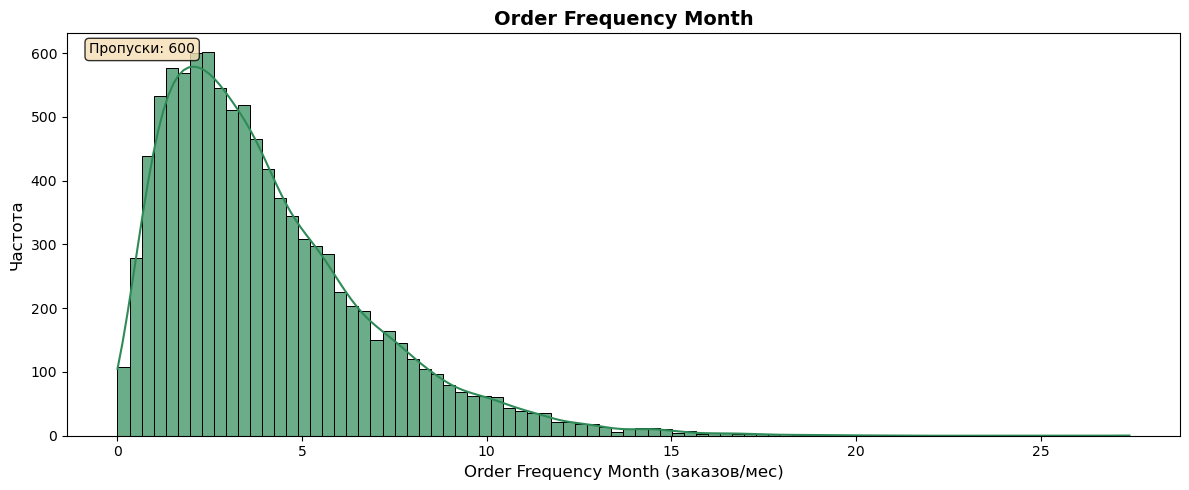

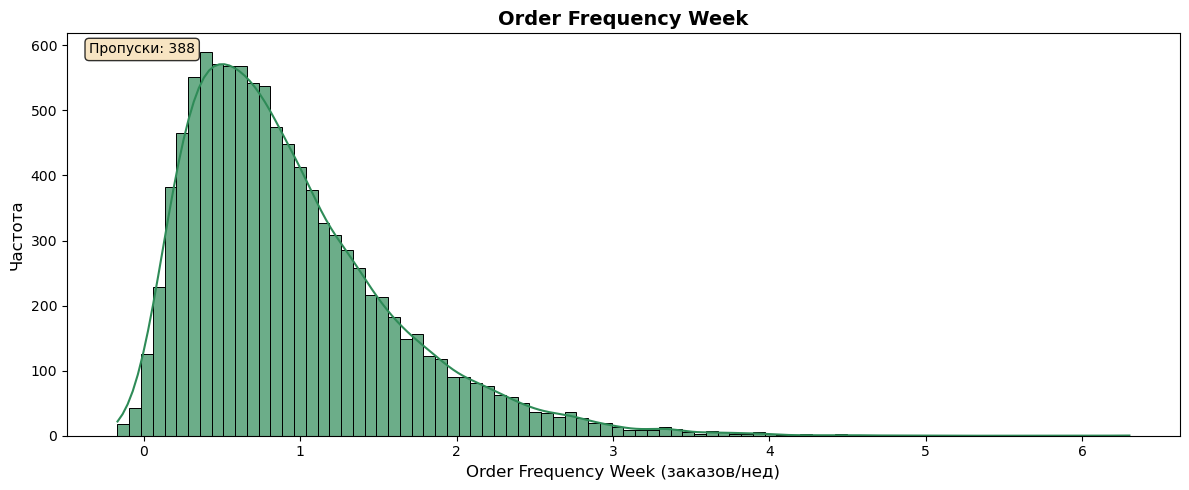

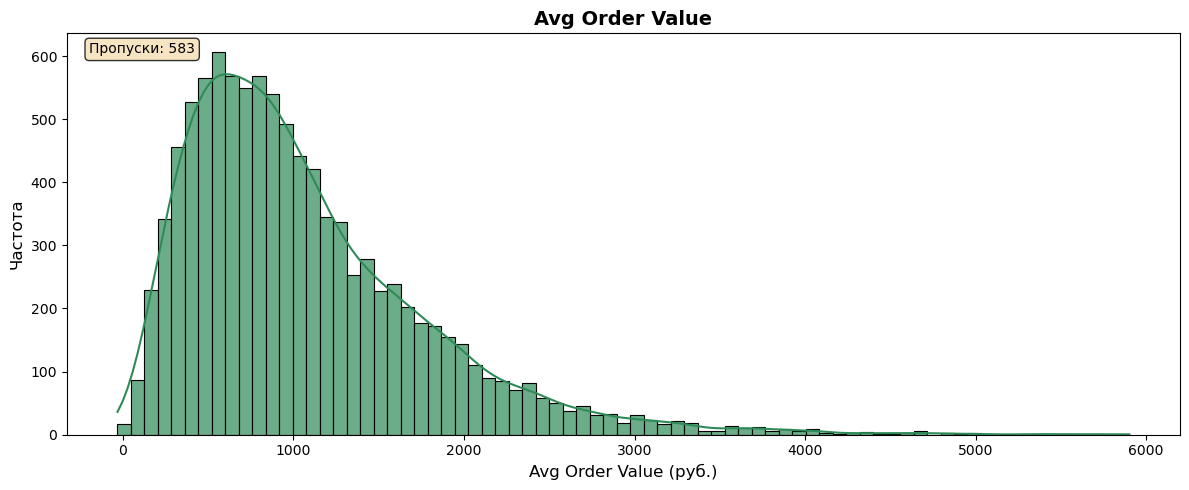

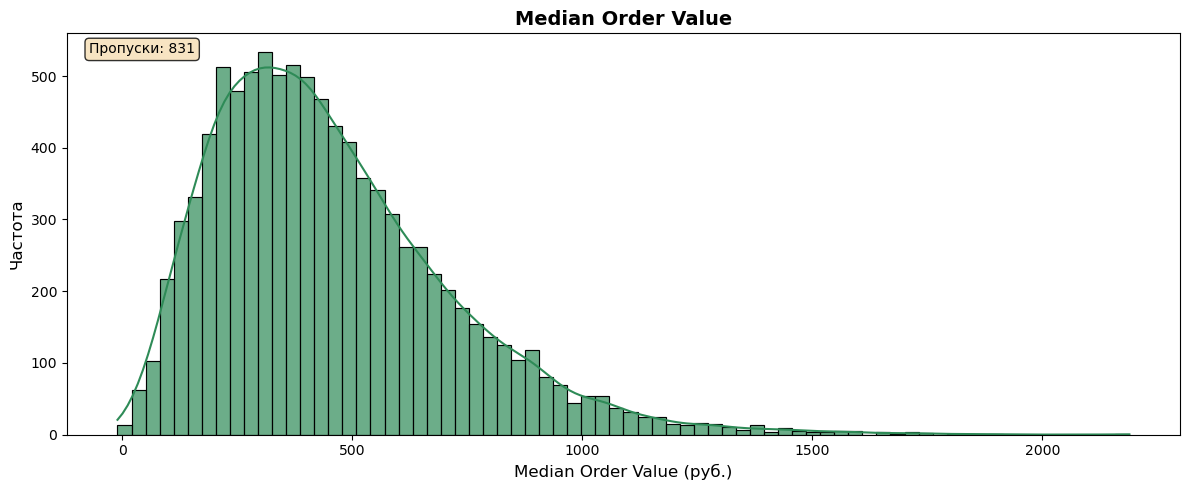

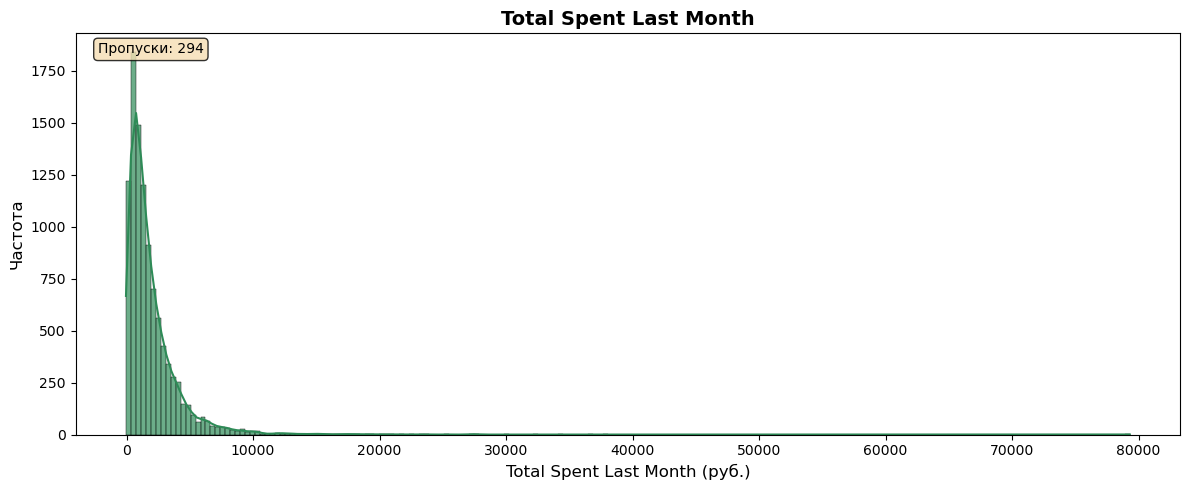

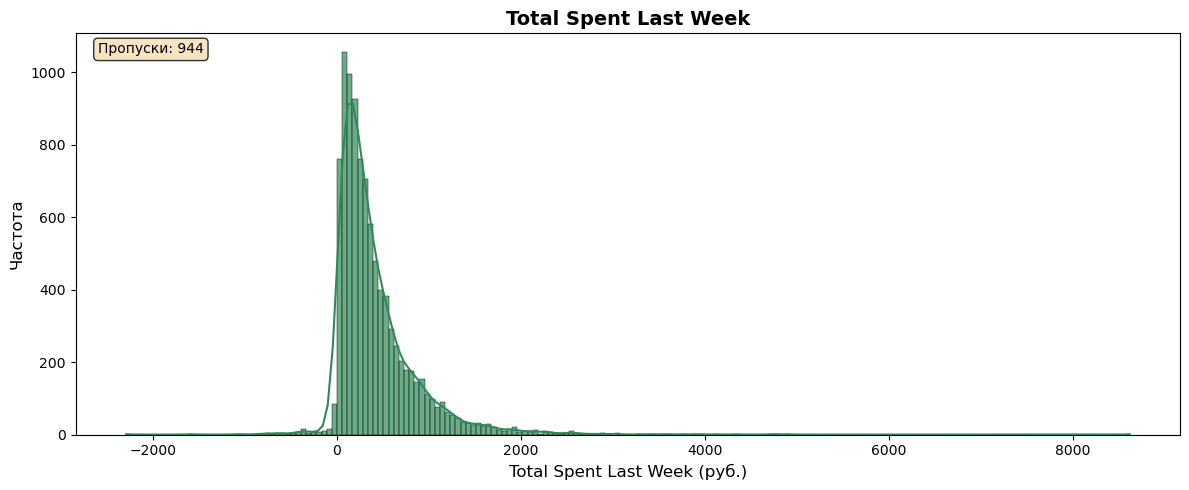

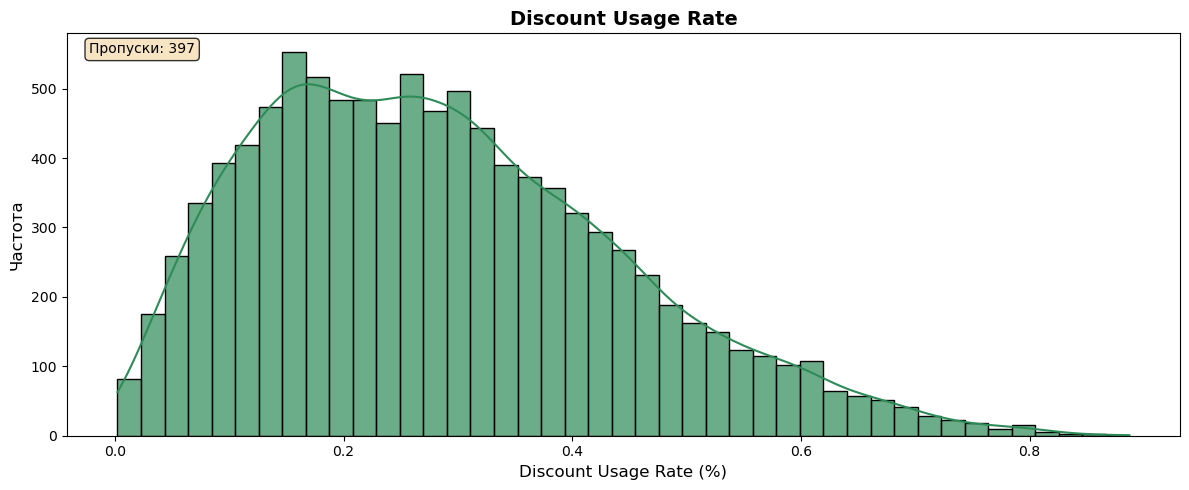

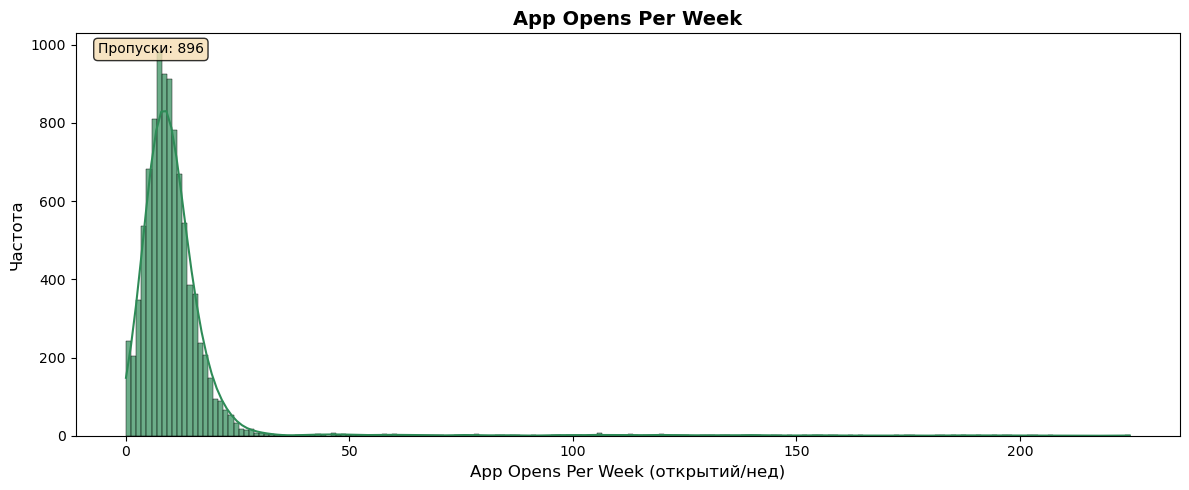

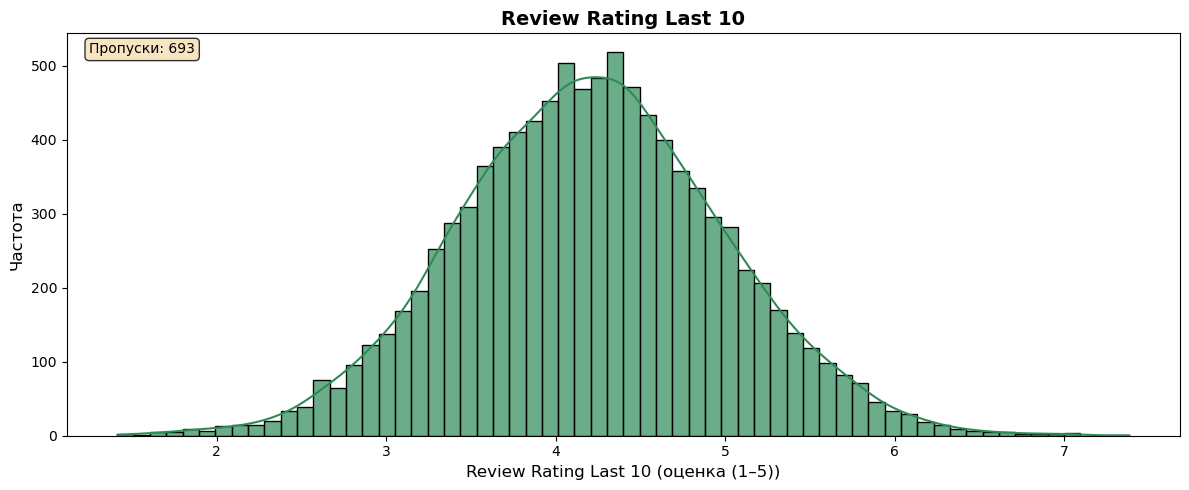

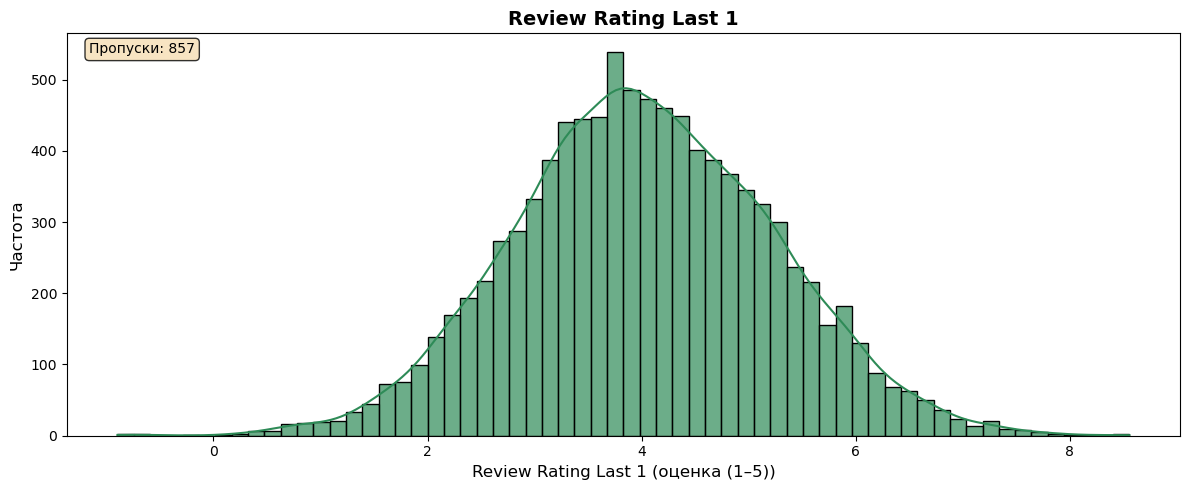

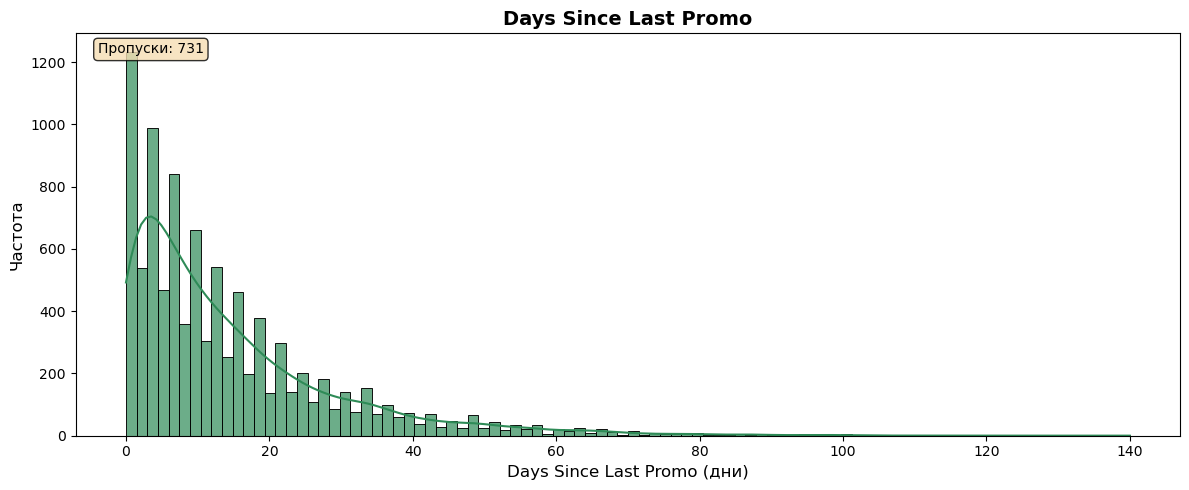

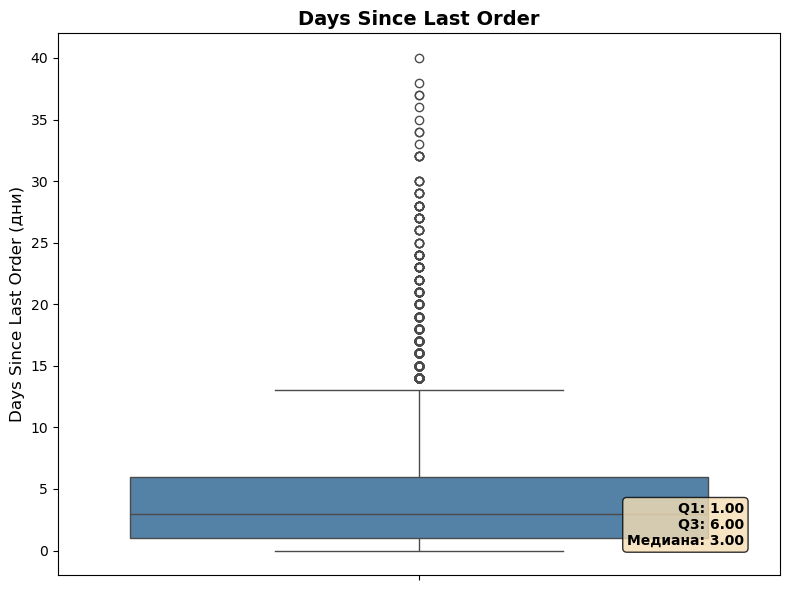

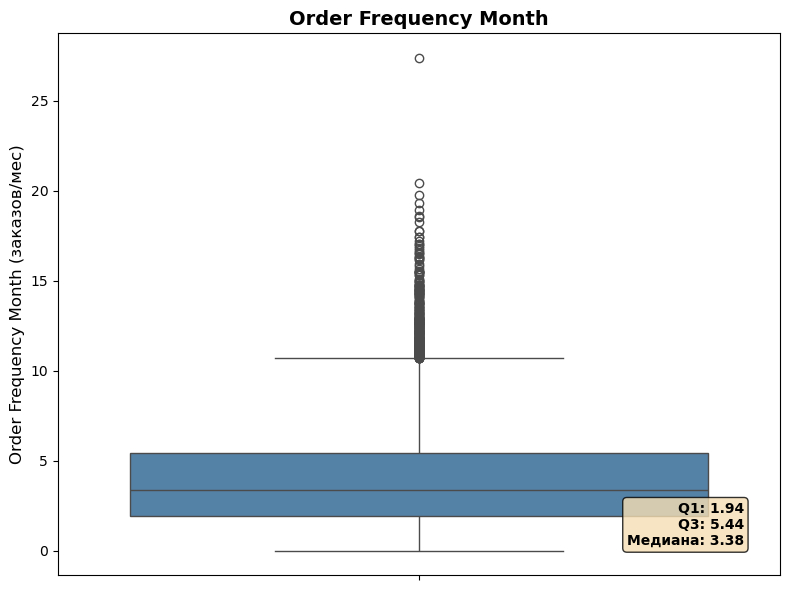

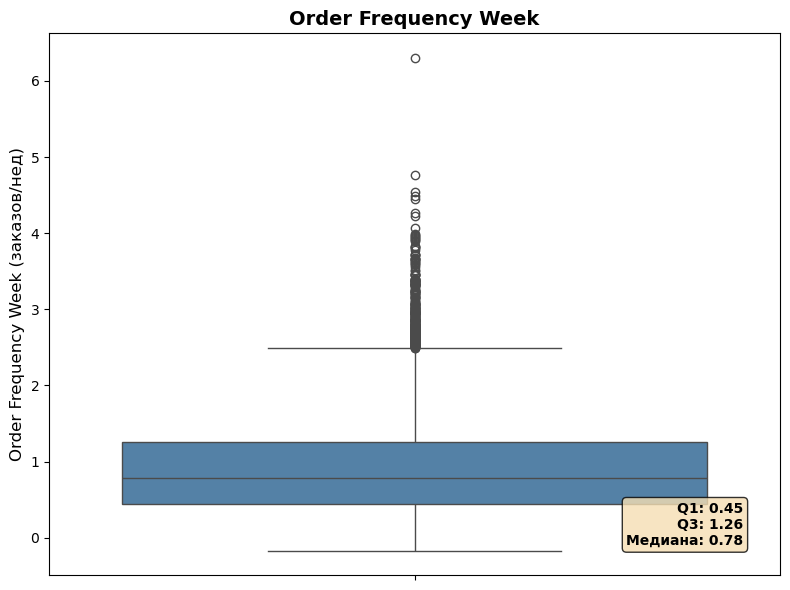

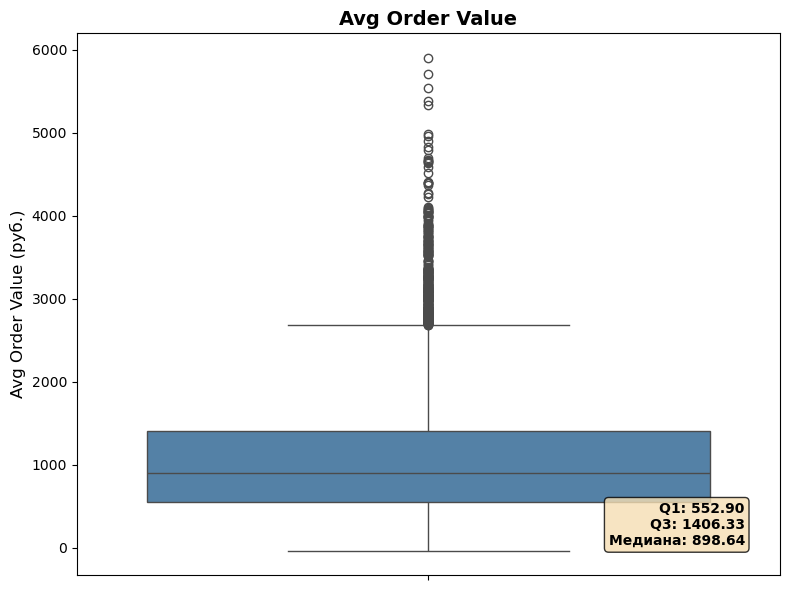

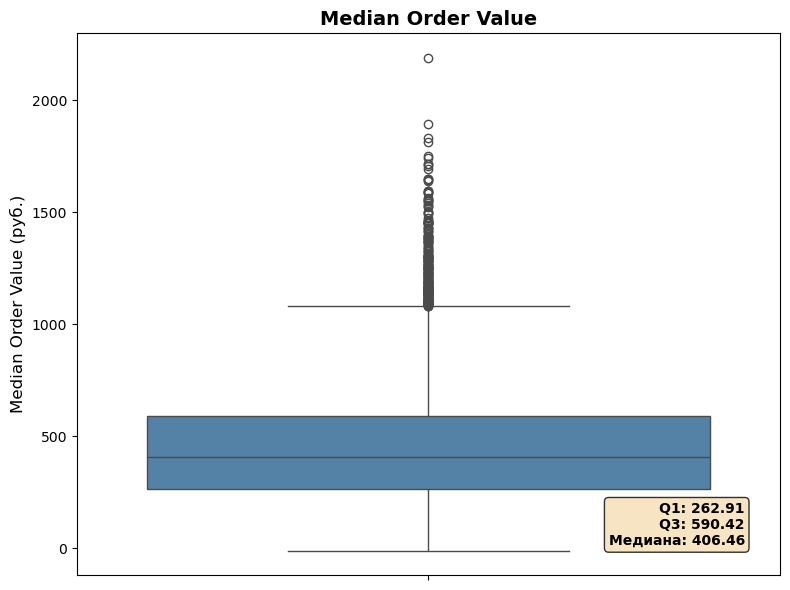

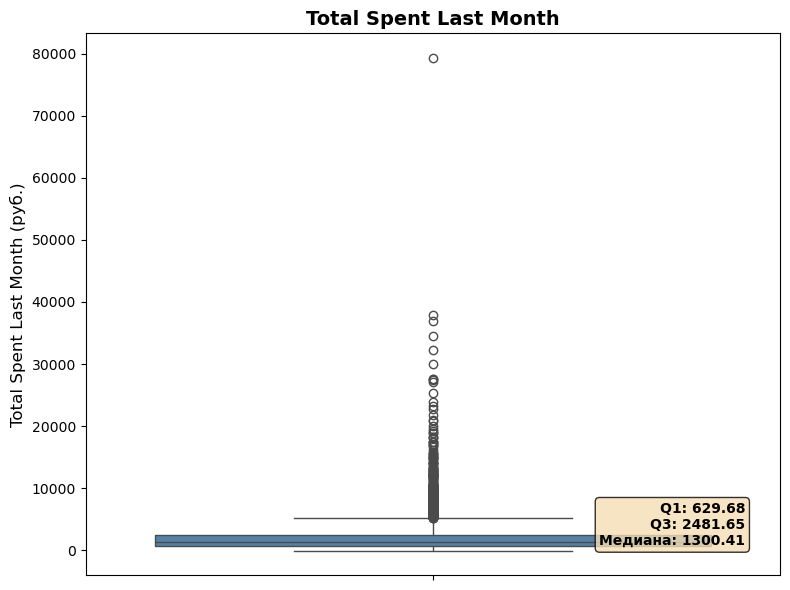

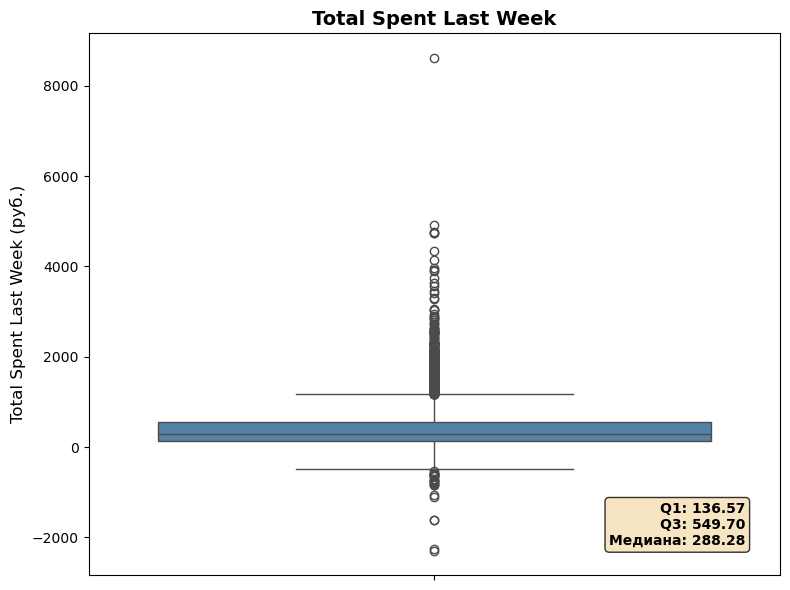

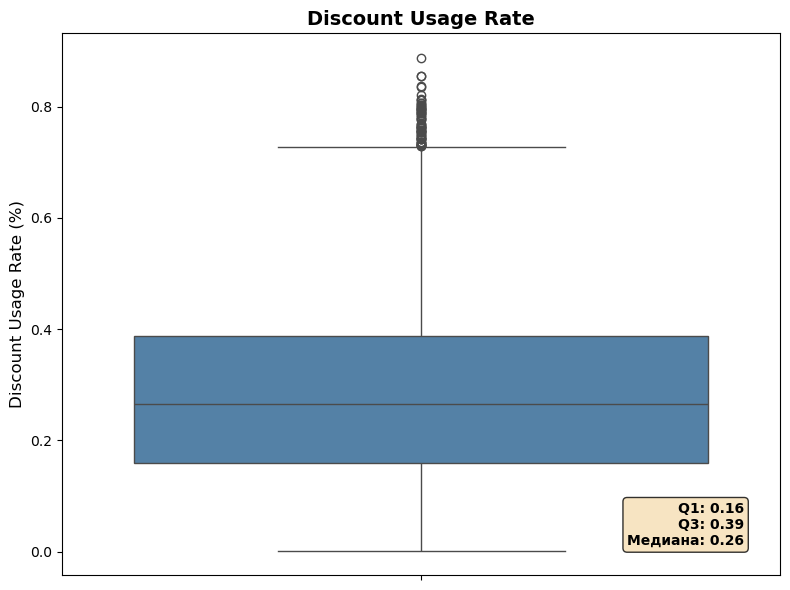

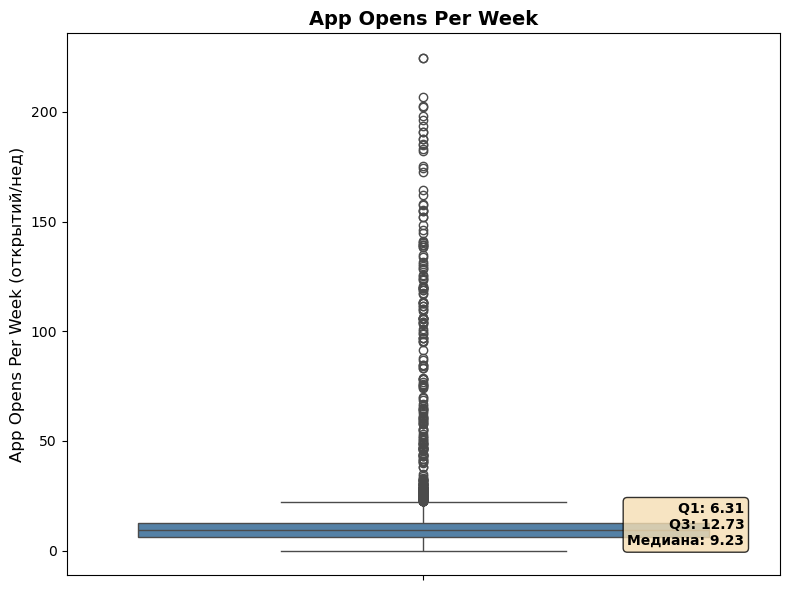

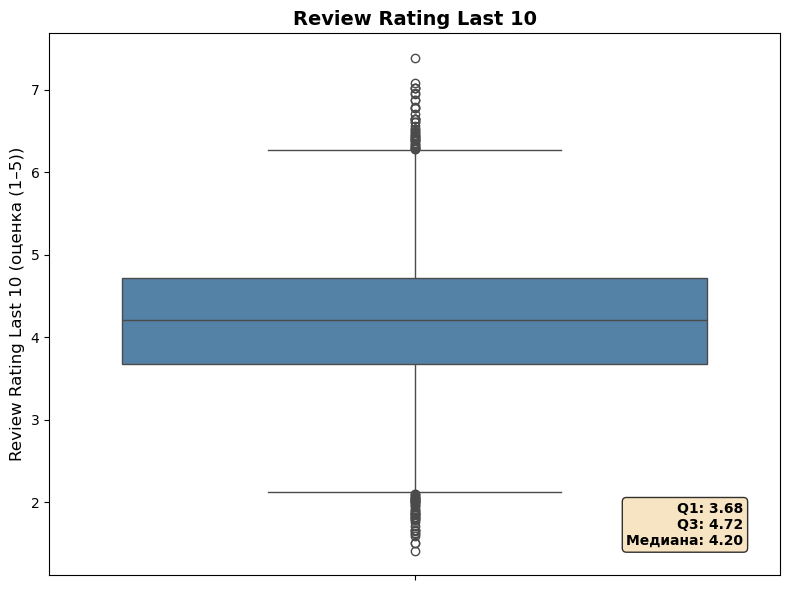

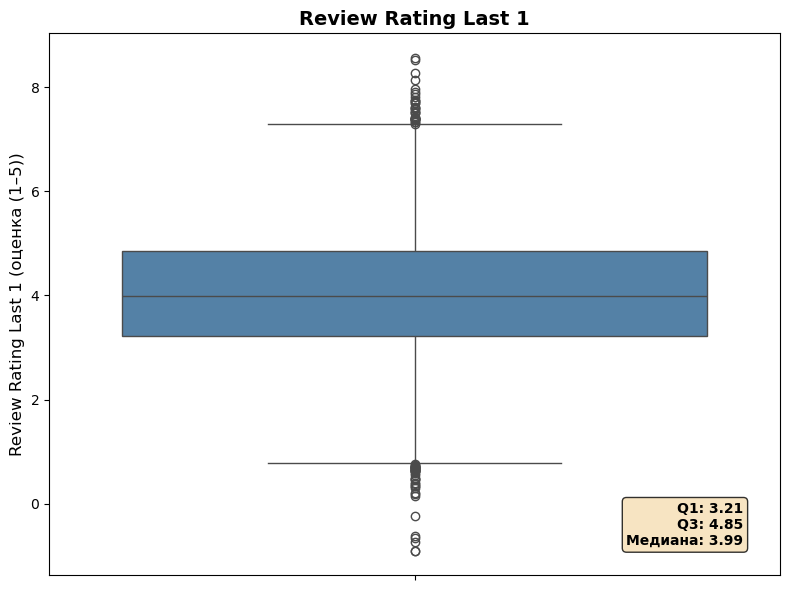

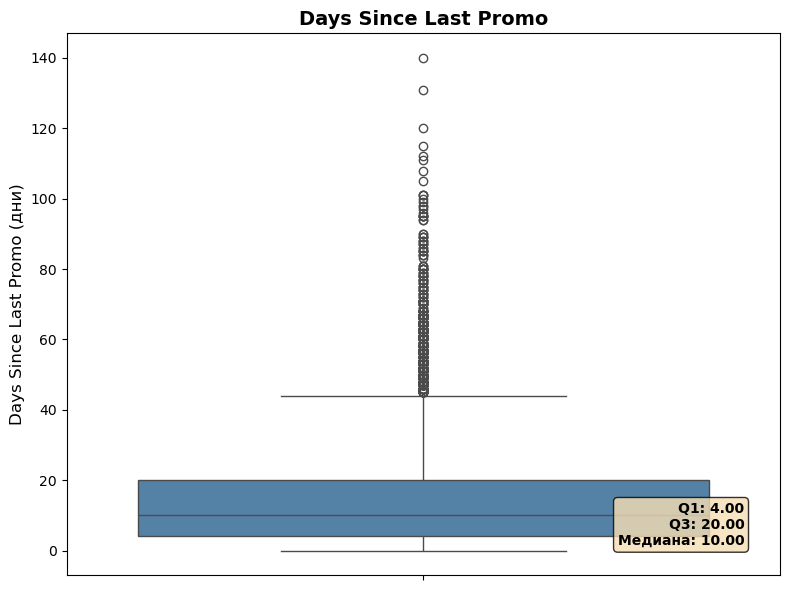

In [11]:
# Настраиваем стиль
features = ['days_since_last_order', 'order_frequency_month', 'order_frequency_week',
            'avg_order_value', 'median_order_value', 'total_spent_last_month',
            'total_spent_last_week', 'discount_usage_rate', 'app_opens_per_week', 'review_rating_last_10',
            'review_rating_last_1',
            'days_since_last_promo']

# Словарь с единицами измерения для каждого признака
units_of_measurement = {
    'days_since_last_order': 'дни',
    'order_frequency_month': 'заказов/мес',
    'order_frequency_week': 'заказов/нед',
    'avg_order_value': 'руб.',
    'median_order_value': 'руб.',
    'total_spent_last_month': 'руб.',
    'total_spent_last_week': 'руб.',
    'discount_usage_rate': '%',
    'app_opens_per_week': 'открытий/нед',
    'review_rating_last_10': 'оценка (1–5)',
    'review_rating_last_1': 'оценка (1–5)',
    'days_since_last_promo': 'дни'
}

# Определяем количество строк и столбцов для сетки графиков
n_features = len(features)
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols  # округление вверх

# === ПЕРВАЯ ФИГУРА: ГИСТОГРАММЫ (каждая на отдельном рисунке) ===
for idx, feature in enumerate(features):
    # Создаём отдельную фигуру для каждой гистограммы
    fig, ax = plt.subplots(figsize=(12, 5))
    
    # Гистограмма с KDE
    sns.histplot(data=data, x=feature, kde=True, ax=ax, color='#2E8B57', alpha=0.7)
    ax.set_title(feature.replace('_', ' ').title(), fontweight='bold', fontsize=14)
    
    # Подписываем ось X с единицами измерения
    unit = units_of_measurement.get(feature, '')
    if unit:
        ax.set_xlabel(f'{feature.replace("_", " ").title()} ({unit})', fontsize=12)
    else:
        ax.set_xlabel(feature.replace('_', ' ').title(), fontsize=12)
    ax.set_ylabel('Частота', fontsize=12)
    
    # Если признак содержит пропуски, указываем их количество в заголовке
    n_missing = data[feature].isnull().sum()
    if n_missing > 0:
        ax.text(0.02, 0.95, f'Пропуски: {n_missing}', transform=ax.transAxes,
                fontsize=10, bbox=dict(boxstyle='round', facecolor="wheat", alpha=0.8))
    
    plt.tight_layout()
    plt.show()

# === ВТОРАЯ ФИГУРА: БОКСПЛОТЫ (каждая на отдельном рисунке) ===
for idx, feature in enumerate(features):
    # Создаём отдельную фигуру для каждого боксплота
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # Боксплот
    sns.boxplot(data=data, y=feature, ax=ax, color='#4682B4')
    ax.set_title(feature.replace('_', ' ').title(), fontweight='bold', fontsize=14)
    
    # Подписываем ось Y с единицами измерения
    unit = units_of_measurement.get(feature, '')
    if unit:
        ax.set_ylabel(f'{feature.replace("_", " ").title()} ({unit})', fontsize=12)
    else:
        ax.set_ylabel(feature.replace('_', ' ').title(), fontsize=12)
    
    # Добавляем статистику в виде текста
    stats = data[feature].describe()
    text_str = f'Q1: {stats["25%"]:.2f}\nQ3: {stats["75%"]:.2f}\nМедиана: {stats["50%"]:.2f}'
    ax.text(0.95, 0.05, text_str, transform=ax.transAxes, fontsize=10,
            verticalalignment='bottom', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
            fontweight='bold')
    
    plt.tight_layout()
    plt.show()


АНАЛИЗ ДИСКРЕТНЫХ ПРИЗНАКОВ


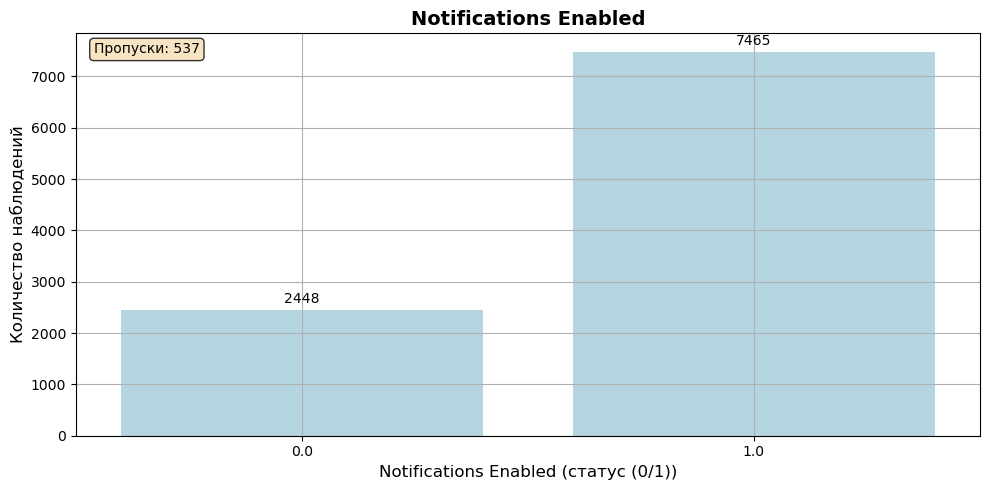

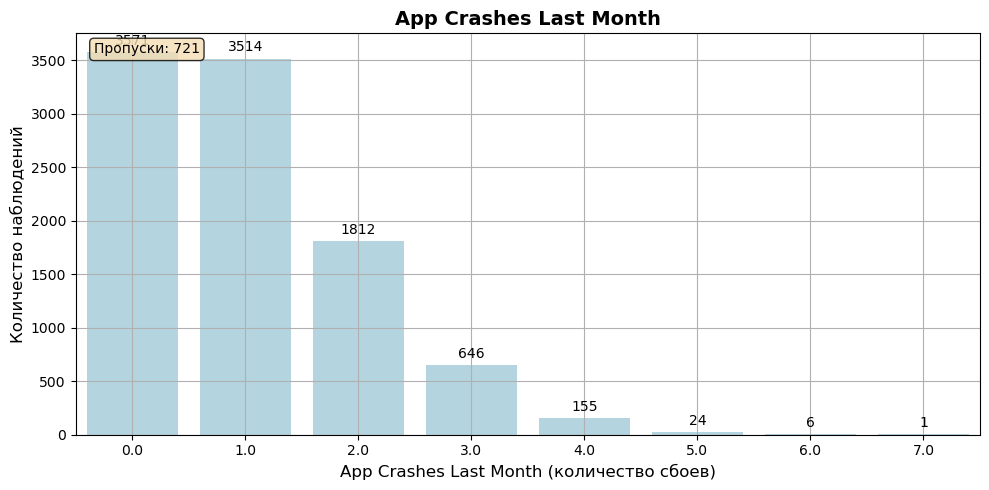

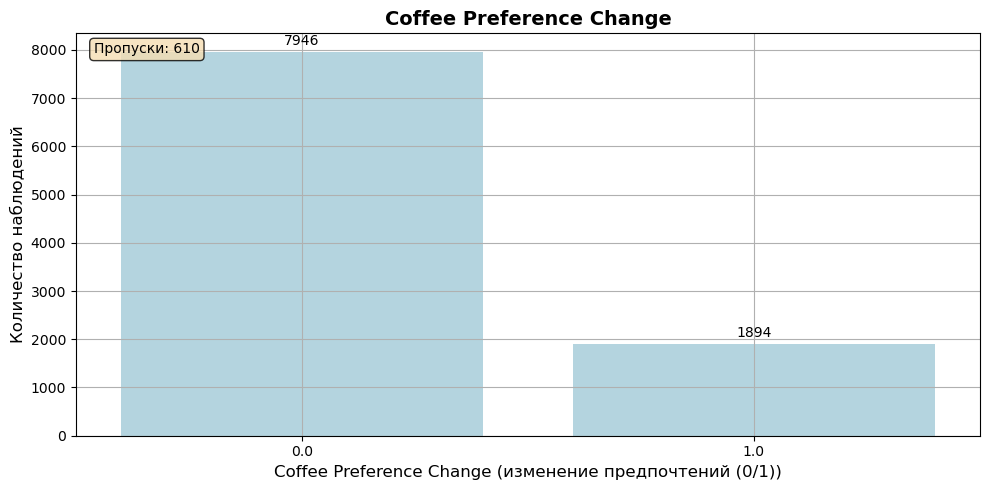

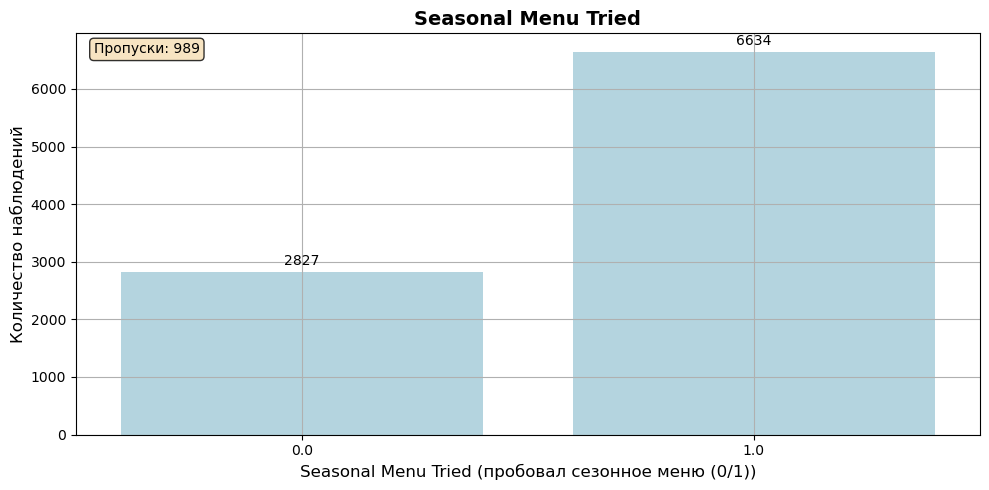

In [12]:
# Список дискретных признаков
discrete_features = ['notifications_enabled', 'app_crashes_last_month',
                   'coffee_preference_change', 'seasonal_menu_tried']

# Словарь с единицами измерения для дискретных признаков
units_of_measurement = {
    'notifications_enabled': 'статус (0/1)',
    'app_crashes_last_month': 'количество сбоев',
    'coffee_preference_change': 'изменение предпочтений (0/1)',
    'seasonal_menu_tried': 'пробовал сезонное меню (0/1)'
}

print("АНАЛИЗ ДИСКРЕТНЫХ ПРИЗНАКОВ")
print("=" * 50)

for feature in discrete_features:
    # Создаём фигуру для каждого графика
    fig, ax = plt.subplots(figsize=(10, 5))
    
    
    # Countplot для дискретного признака
    sns.countplot(data=data, x=feature, ax=ax, color = 'lightblue')
    ax.set_title(feature.replace('_', ' ').title(), fontweight='bold', fontsize=14)
    
    
    # Подписываем ось X с единицами измерения
    unit = units_of_measurement.get(feature, '')
    if unit:
        ax.set_xlabel(f'{feature.replace("_", " ").title()} ({unit})', fontsize=12)
    else:
        ax.set_xlabel(feature.replace('_', ' ').title(), fontsize=12)
    ax.set_ylabel('Количество наблюдений', fontsize=12)
    
    # Добавляем числовые значения над столбцами (альтернативный способ)
    for p in ax.patches:
        height = p.get_height()
        if not pd.isna(height):  # Проверяем, что значение не NaN
            ax.annotate(f'{int(height)}',
                        xy=(p.get_x() + p.get_width() / 2, height),
                        xytext=(0, 3),  # 3 точки вертикального отступа
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=10)
    
    # Если признак содержит пропуски, указываем их количество в заголовке
    n_missing = data[feature].isnull().sum()
    if n_missing > 0:
        ax.text(0.02, 0.95, f'Пропуски: {n_missing}', transform=ax.transAxes,
                fontsize=10, bbox=dict(boxstyle='round', facecolor="wheat", alpha=0.8))
    plt.grid()
    plt.tight_layout()
    plt.show()

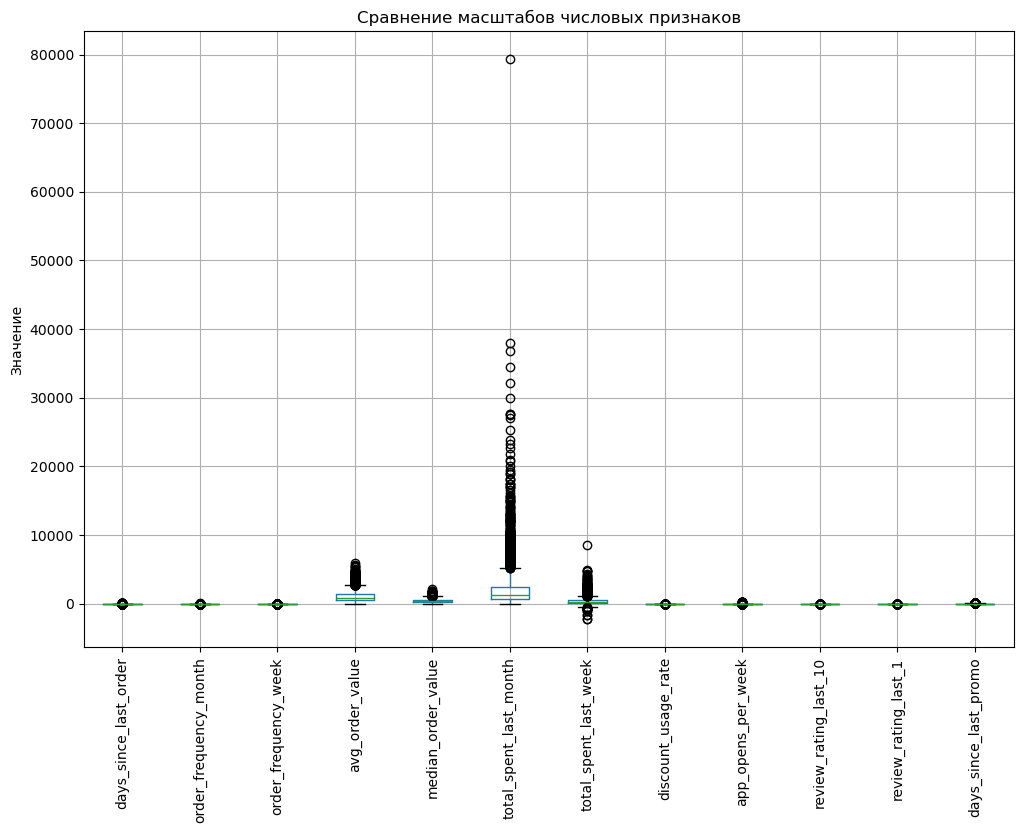

In [13]:
#Визуализируем масштаб данных

plt.figure (figsize= (12, 8))

# Строим boxplot (диаграмму размаха) для всех признаков

data.boxplot (column = features, rot = 90)

plt.title ('Сравнение масштабов числовых признаков')
plt.ylabel ('Значение')

plt.show ()

**Промежуточный вывод по распределению значений**

По графикам видно, что выбросы присутствуют во всех полях.  
- Данные в полях `review_rating_last_10`,`review_rating_last_1` и `discount_usage_rate` - имеют нормальное распределение, остальные же имеют сильное смещение вправо с большим количеством выбросов, эту проблему мы решим преобразованием. В контексте нашей задачи выбросы могут оказывать большое влияние на целевую переменную, поэтому избавляться от них было бы некорректно

- Поле `total_spent_last_month` имеет одно необъяснимо огромное значение, существенно превышающее большинство выбросов, скорее всего аномальное значение связано с ошибкой в данных. Его можно удалить.

- Поля `order_frequency_week`, `avg_order_value`, `median_order_value`, `total_spent_last_month`, `total_spent_last_week`, `review_rating_last_1` имеют отрицательные значения. Значение рейтинга не может быть отрицательным, скорее всего это ошибка ввода, заменим на 0. Остальные признаки имеют ценовую и количественную информацию, отрицательные значения в них в полне возможны(возвраты и отмены). 


In [14]:
#Удаляем аномально значение стобца total_spent_last_month
data = data[(data['total_spent_last_month'] < 70000) | (data['total_spent_last_month'].isna())]

In [15]:
negative_values = ['order_frequency_week',
                   'avg_order_value',
                   'median_order_value',
                   'total_spent_last_month',
                   'total_spent_last_week',
                   'review_rating_last_1']

total_negative_count = 0

for col in negative_values:
   
    negative_mask = data[col] < 0
    negative_count = negative_mask.sum()
    total_negative_count += negative_count
    
    
    negative_percentage = (negative_count / len(data)) * 100
    
    if negative_count > 0:
        
        min_neg = data.loc[negative_mask, col].min()
        max_neg = data.loc[negative_mask, col].max()
        mean_neg = data.loc[negative_mask, col].mean()
        
        print(f"\nСтолбец: {col}")
        print(f"  Количество отрицательных значений: {negative_count}")
        print(f"  Доля отрицательных значений: {negative_percentage:.2f}%")
        print(f"  Минимальное отрицательное значение: {min_neg:.2f}")
        print(f"  Максимальное отрицательное значение: {max_neg:.2f}")
        print(f"  Среднее отрицательное значение: {mean_neg:.2f}")

print("\n" + "=" * 60)
print(f"ОБЩАЯ СТАТИСТИКА:")
print(f"Всего столбцов с потенциальными отрицательными значениями: {len(negative_values)}")

print(f"Общее количество отрицательных значений во всех указанных столбцах: {total_negative_count}")
print(f"Доля отрицательных значений от общего числа наблюдений: {total_negative_count / (len(data) * len(negative_values)) * 100:.2f}%")


Столбец: order_frequency_week
  Количество отрицательных значений: 83
  Доля отрицательных значений: 0.79%
  Минимальное отрицательное значение: -0.17
  Максимальное отрицательное значение: -0.00
  Среднее отрицательное значение: -0.06

Столбец: avg_order_value
  Количество отрицательных значений: 2
  Доля отрицательных значений: 0.02%
  Минимальное отрицательное значение: -32.08
  Максимальное отрицательное значение: -24.97
  Среднее отрицательное значение: -28.52

Столбец: median_order_value
  Количество отрицательных значений: 2
  Доля отрицательных значений: 0.02%
  Минимальное отрицательное значение: -10.35
  Максимальное отрицательное значение: -7.33
  Среднее отрицательное значение: -8.84

Столбец: total_spent_last_month
  Количество отрицательных значений: 2
  Доля отрицательных значений: 0.02%
  Минимальное отрицательное значение: -43.72
  Максимальное отрицательное значение: -14.74
  Среднее отрицательное значение: -29.23

Столбец: total_spent_last_week
  Количество отрицате

**Промежуточный вывод по полям с отрицательными значениями**
1. order_frequency_week (частота заказов в неделю)

- Проблема: отрицательные значения не имеют смысла (частота не может быть отрицательной).

- Характер: значения очень близки к нулю (−0,17…−0,00), вероятно, это округлённые нули или артефакты вычислений.

- Рекомендация: заменить все отрицательные значения на 0.

2. total_spent_last_week (траты за последнюю неделю)

- Проблема: 169 отрицательных значений (1,66 %) с широким диапазоном (−2 290,56…−0,29).

- Возможные причины: возвраты средств, ошибки ввода данных, корректировки транзакций.

- Рекомендация: проверить бизнес‑логику: разрешены ли возвраты в системе? Если возвраты допустимы — оставить как есть (но учесть при моделировании). Если это ошибки — заменить на NaN или 0, либо удалить строки. В нашем случае, большие отрицательные значения могут существенно повлиять на обучение модели, рациональнее будет удалить этот столбец.

3. avg_order_value и median_order_value (средний и медианный чек)

- Проблема: по 2 отрицательных значения (−32,08…−24,97 и −10,35…−7,33).

- Причина: почти наверняка ошибка ввода или расчёта.

- Рекомендация: заменить на NaN, затем провести импутацию (медианой или средним по группе).

4. total_spent_last_month (траты за последний месяц)

- Проблема: 2 отрицательных значения (−43,72 и −14,74).

- Причина: вероятная ошибка ввода.

- Рекомендация: заменить на NaN, далее — импутация медианой.

5. review_rating_last_1 (рейтинг последнего отзыва)

- Проблема: 6 отрицательных значений (−0,90…−0,24).

- Причина: явная ошибка — рейтинги обычно лежат в диапазоне [0, 5] или [1, 5].

- Рекомендация: заменить на NaN, затем заполнить медианой или модой.

In [16]:
#Заменяем отрицательные значения на 0
for col in negative_values:
    data[col] = data[col].apply(lambda x: 0 if x < 0 else x)
    
#Удаляем поле total_spent_last_week
data = data.drop (columns = ['total_spent_last_week'])
data = data.drop (columns = ['user_id'])

### Корреляция признаков

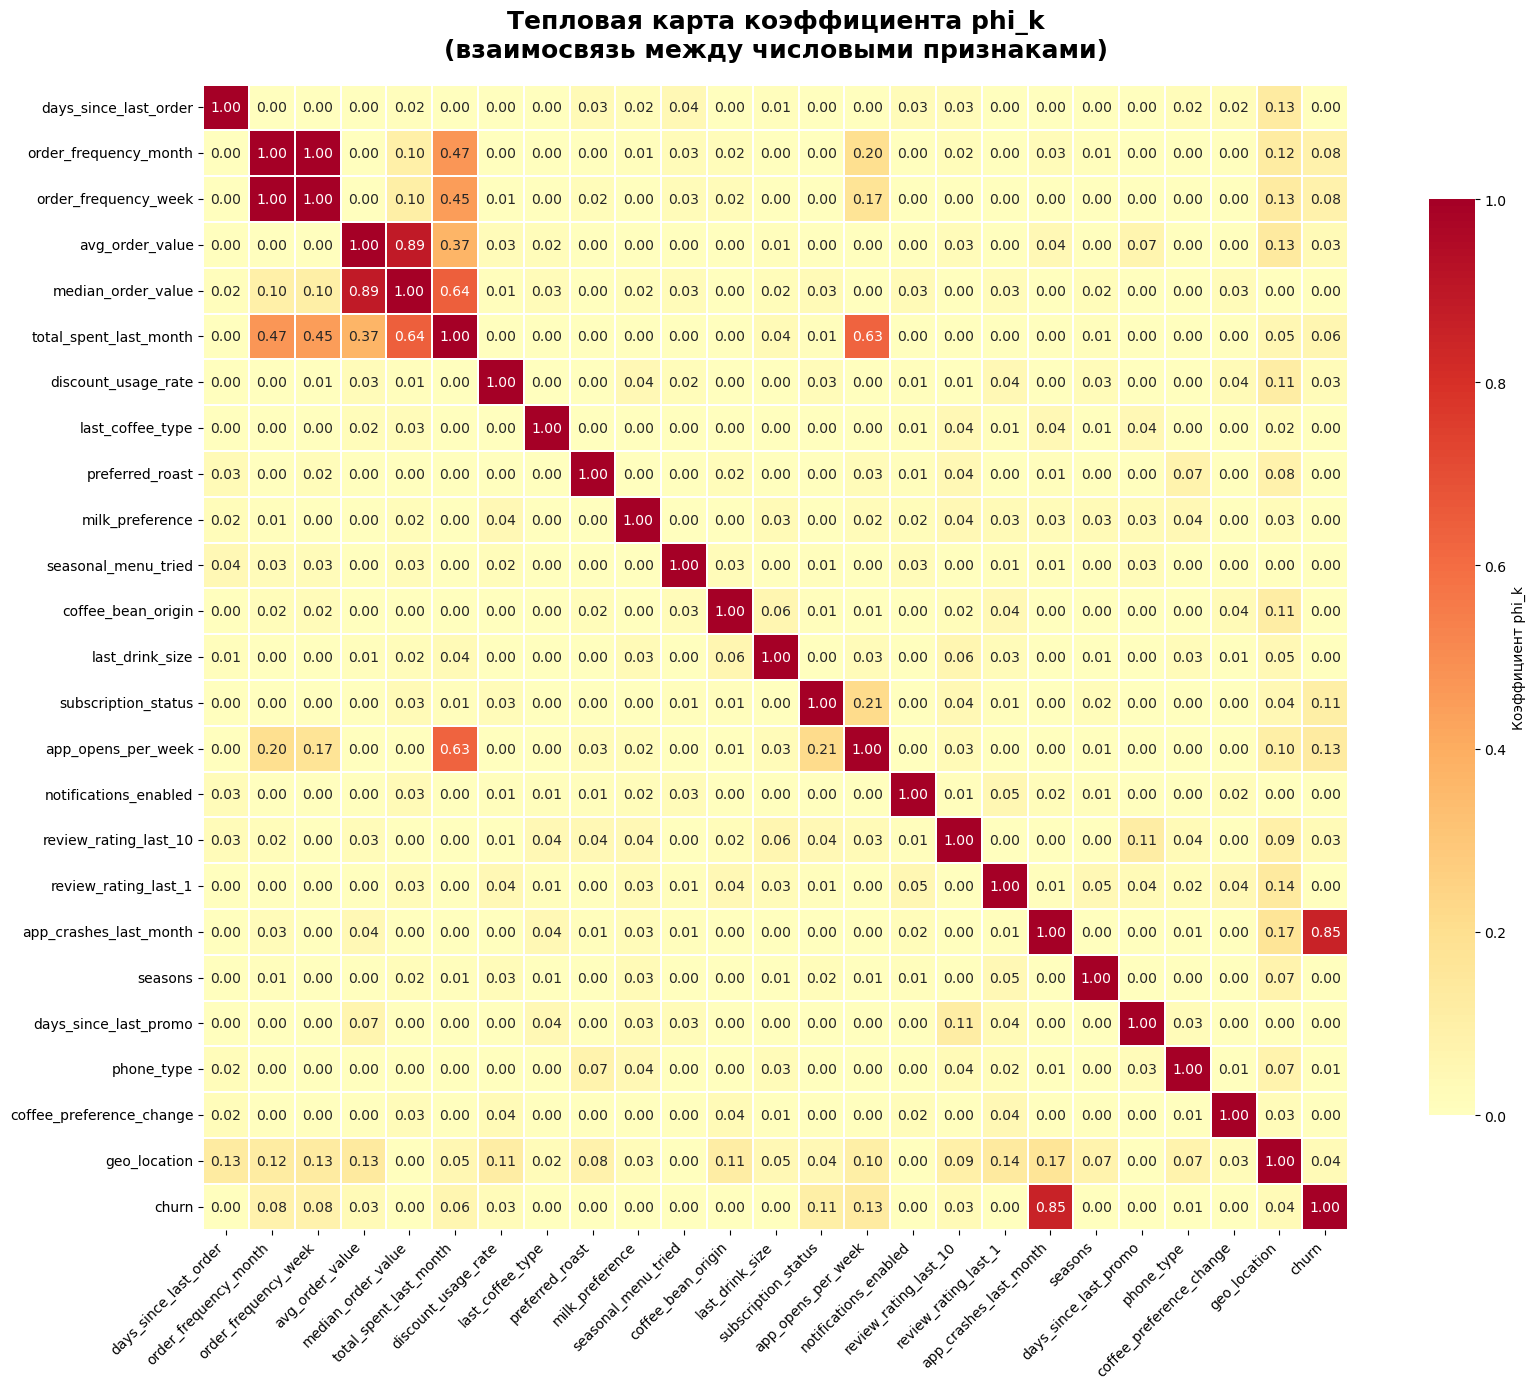

СИЛЬНЫЕ КОРРЕЛЯЦИИ (|phi_k| > 0.5):
order_frequency_month ↔ order_frequency_week: 0.996
avg_order_value ↔ median_order_value: 0.890
app_crashes_last_month ↔ churn: 0.854
median_order_value ↔ total_spent_last_month: 0.641
total_spent_last_month ↔ app_opens_per_week: 0.629


In [17]:
# Вычисляем матрицу корреляций
correlation_matrix = data.phik_matrix(
    interval_cols=[
        'days_since_last_order', 'order_frequency_month', 'order_frequency_week',
        'avg_order_value', 'median_order_value', 'total_spent_last_month',
        'discount_usage_rate', 'review_rating_last_10', 'review_rating_last_1',
        'app_opens_per_week', 'days_since_last_promo'
    ]
)

# Создаём фигуру с увеличенным размером
plt.figure(figsize=(18, 14))

# Тепловая карта с улучшенной читаемостью
heatmap = sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdYlBu_r',  # Красная-жёлтая-синяя палитра (обратная)
    center=0,  # Центрируем цветовую шкалу на 0
    linewidths=0.3,
    linecolor='white',  # Цвет линий между ячейками
    cbar=True,  # Показываем цветовую шкалу
    cbar_kws={'label': 'Коэффициент phi_k', 'shrink': 0.8},
    square=True,
    annot_kws={'size': 10}  # Размер шрифта аннотаций
)

# Настройка заголовка
plt.title(
    'Тепловая карта коэффициента phi_k\n(взаимосвязь между числовыми признаками)',
    fontsize=18,
    fontweight='bold',
    pad=20
)

# Поворот меток осей для лучшей читаемости
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

# Оптимизация расположения элементов
plt.tight_layout()
plt.show()

# Дополнительно: вывод сильных корреляций (> 0.5)
print("СИЛЬНЫЕ КОРРЕЛЯЦИИ (|phi_k| > 0.5):")
strong_corr = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i + 1, len(correlation_matrix.columns)):
        corr_value = correlation_matrix.iloc[i, j]
        if abs(corr_value) > 0.5:
            strong_corr.append((
                correlation_matrix.columns[i],
                correlation_matrix.columns[j],
                corr_value
            ))

if strong_corr:
    for col1, col2, corr in sorted(strong_corr, key=lambda x: abs(x[2]), reverse=True):
        print(f"{col1} ↔ {col2}: {corr:.3f}")
else:
    print("Сильных корреляций не обнаружено")


**Промежуточный вывод по тепловой карте**

По тепловой карте можем наблюдать сильную корреляцию частоты зависаний приложения с целевлой переменной, что вполне логично. 
Также можем наблюдать явление мультиколлинеарности, на которую указывают сильные кореляции `order_frequency_month` ↔ `order_frequency_week`: 0.996, поскольку корреляция почти 1, эти признаки несут практически одинаковую информаци, оставляем order_frequency_month, так как месячный период даёт более стабильную оценку поведения клиента.  `avg_order_value` ↔ `median_order_value`: 0.890, медианное значение менее чувствительно к выбросам, поэтому предпочтительнее оставить median_order_value. Это даст более надёжную оценку типичной стоимости заказа.





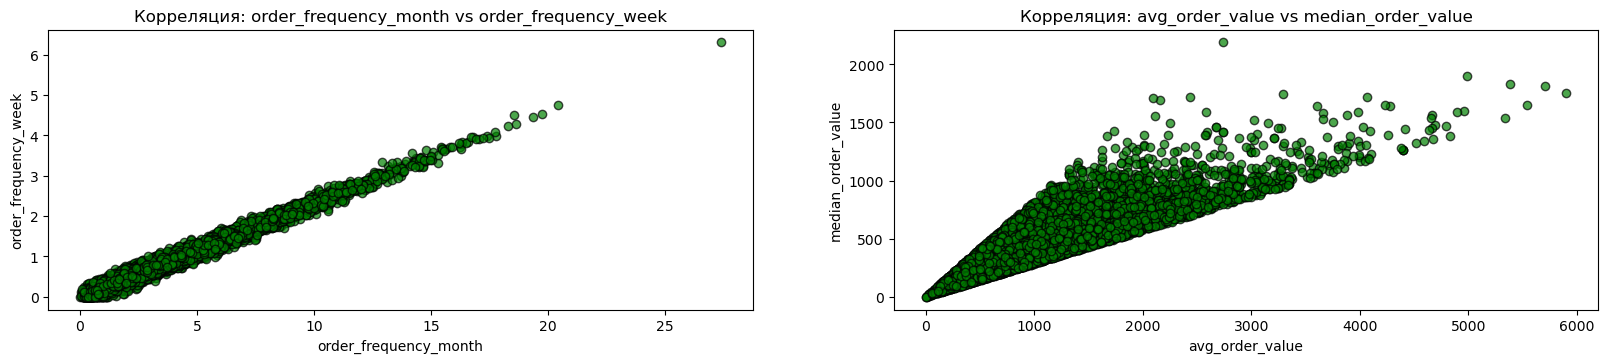

In [18]:
#Визуализируем зависимость признаков с наибольшей корреляцией 
plt.figure (figsize=(20, 8))
plt.subplot (2, 2, 1)
plt.scatter (x=data['order_frequency_month'], 
            y=data['order_frequency_week'],
            alpha=0.7,
            color='green',
            edgecolor='k')
plt.xlabel('order_frequency_month')
plt.ylabel('order_frequency_week')
plt.title(f'Корреляция: order_frequency_month vs order_frequency_week')

plt.subplot (2, 2, 2)
plt.scatter (x=data['avg_order_value'], 
            y=data['median_order_value'],
            alpha=0.7,
            color='green',
            edgecolor='k')
plt.xlabel('avg_order_value')
plt.ylabel('median_order_value')
plt.title(f'Корреляция: avg_order_value vs median_order_value')

plt.show()

In [19]:
#Удалим столбцы
columns_to_drop = ['order_frequency_week', 'avg_order_value']  
data = data.drop(columns_to_drop, axis=1)

### Вывод по проделанной работе
**Проведённый анализ данных позволил сделать ряд важных выводов и наметить план предобработки:**

- Датасет оказался достаточно полным и актуальным для построения модели, а типы данных во всех колонках соответствуют ожидаемым значениям. Однако сразу бросается в глаза сильный дисбаланс классов в целевой переменной: всего 629 клиентов ушли, тогда как 9 821 остались.

- Некоторые признаки были признаны избыточными или некорректными. Так, user_id не несёт полезной информации для модели и был исключён. Признаки total_spent_last_week и avg_order_value также удалены на основе анализа корреляций и выбросов, способных осложнить обучение.

- В данных обнаружены пропуски, но их немного, и они разбросаны по разным признакам. Учитывая дисбаланс классов, мы решили не удалять такие строки, а восполнить пропуски расчётными значениями или специальными индикаторами.

- Большое число категориальных признаков требует кодирования. Мы применим One Hot Encoder для категорий с небольшим числом уникальных значений (до 15), TargetEncoder для geo_location и Ordinal Encoder для порядковых данных.

- Выбросы присутствуют почти во всех числовых признаках, но для нашей задачи они естественны. Мы протестируем несколько стратегий: сохраним выбросы без изменений, преобразуем признаки, создадим новые и применим регуляризацию. Лучший подход выберем по результатам сравнения метрик.

- В ряде признаков (order_frequency_week, avg_order_value, median_order_value, total_spent_last_month, review_rating_last_1) найдены отрицательные значения, не имеющие смысла в контексте. Они были заменены на 0.

In [20]:
# Проверим долю потерь после обработки
original_rows, processed_rows = len(data), len(temp)
original_cols, processed_cols = len(data.columns), len(temp.columns)

loss_percentage = round((original_rows - processed_rows) / original_rows * 100, 2)

print(f"📊 АНАЛИЗ ПОТЕРЬ ДАННЫХ ПОСЛЕ ОБРАБОТКИ\n")
print(f"┌{'─' * 40}")
print(f"│ Исходный размер:")
print(f"│   • Строк: {original_rows:,}")
print(f"│   • Столбцов: {original_cols}")
print(f"├{'─' * 40}")
print(f"│ После обработки:")
print(f"│   • Осталось строк: {processed_rows:,}")
print(f"│   • Стало столбцов: {processed_cols}")
print(f"├{'─' * 40}")
print(f"│ Потери:")
print(f"│   • Удалено строк: {original_rows - processed_rows:,}")
print(f"│   • Процент потерь: {loss_percentage}%")
print(f"└{'─' * 40}")


📊 АНАЛИЗ ПОТЕРЬ ДАННЫХ ПОСЛЕ ОБРАБОТКИ

┌────────────────────────────────────────
│ Исходный размер:
│   • Строк: 10,449
│   • Столбцов: 23
├────────────────────────────────────────
│ После обработки:
│   • Осталось строк: 10,450
│   • Стало столбцов: 27
├────────────────────────────────────────
│ Потери:
│   • Удалено строк: -1
│   • Процент потерь: -0.01%
└────────────────────────────────────────


## Предобработка данных
Разделяем данные на тренировочную и тестовую выборки. 

In [21]:
#Признаки
X = data.drop(columns = 'churn')
#Целевая переменная
y = data['churn']

In [22]:
#Делим на обучающую и тестовую выборки
X_train_val, X_test, y_train_val, y_test = train_test_split (
    X, y,
    test_size = 0.20,
    stratify = y,
    random_state = RANDOM_STATE
)

In [23]:
X_train_val.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8359 entries, 4789 to 2627
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   days_since_last_order     7593 non-null   float64
 1   order_frequency_month     7879 non-null   float64
 2   median_order_value        7682 non-null   float64
 3   total_spent_last_month    8115 non-null   float64
 4   discount_usage_rate       8028 non-null   float64
 5   last_coffee_type          8166 non-null   object 
 6   preferred_roast           8269 non-null   object 
 7   milk_preference           7834 non-null   object 
 8   seasonal_menu_tried       7578 non-null   float64
 9   coffee_bean_origin        7827 non-null   object 
 10  last_drink_size           7964 non-null   object 
 11  subscription_status       7598 non-null   object 
 12  app_opens_per_week        7648 non-null   float64
 13  notifications_enabled     7922 non-null   float64
 14  review_rat

Создаём списки с категориальными и числовыми признаками. Создаем пайплайны обработки.

In [24]:
#Создаём списки числовых и категориальных признаков
num_features = ['days_since_last_order', 'order_frequency_month', 'median_order_value', 'total_spent_last_month', 
            'discount_usage_rate', 'review_rating_last_10', 'review_rating_last_1', 'app_crashes_last_month', 'app_opens_per_week',
            'days_since_last_promo']
cat_features = ['last_coffee_type', 'preferred_roast', 'milk_preference', 'coffee_bean_origin', 
                'phone_type', 'seasons', 'geo_location', 'last_drink_size', 'subscription_status']

#Создаём пайпланы:
#Для числовых признаков
num_pipeline = Pipeline(steps = [
    ('обработка пропусков', SimpleImputer(strategy = 'median')),
    ('масштабирование', StandardScaler())
])

#Для категориальных
cat_pipeline = Pipeline(steps=[
    ('обработка пропусков', SimpleImputer(strategy = 'constant', fill_value= 'missing')),
    ('кодирование признаков', OneHotEncoder(handle_unknown='ignore'))
])

In [25]:
# Объединяем все пайплайны в один ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipeline, num_features),
    ('cat', cat_pipeline, cat_features)
])

## Обучение модели

По условию нам нужно обучить базовую модель (DummyClassifier). Обучим сразу две модели и сравним её с LR. Соотношение целевой переменной в датасете неравномерно, поэтому для оценки качества будет использовать LogLoss  и PR-AUC. 

In [26]:
baseline = Pipeline(steps=[
    ('prep', preprocessor),
    ('basemodel', DummyClassifier(strategy = 'stratified', random_state=RANDOM_STATE))
]) 
logline = Pipeline(steps = [
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(random_state=RANDOM_STATE))
])

In [27]:
# Параметры
N_FOLDS = 5
RANDOM_STATE = 42

# Создаём стратегию кросс‑валидации
kfold = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

# Метрики для оценки
scoring = ['neg_log_loss', 'average_precision']

# Базовая модель (Dummy Classifier)
baseline = DummyClassifier(strategy='prior', random_state=RANDOM_STATE)

# Основная модель (Logistic Regression)
logline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=RANDOM_STATE, max_iter=1000))
])

# Кросс‑валидация базовой модели
print("ПРОВОДИТСЯ КРОСС‑ВАЛИДАЦИЯ...")

cv_results_base = cross_validate(
    estimator=baseline,
    X=X_train_val,
    y=y_train_val,
    scoring=scoring,
    cv=kfold,
    n_jobs=-1
)

base_means = {
    'log_loss': round(np.mean(-cv_results_base['test_neg_log_loss']), 3),
    'pr_auc': round(np.mean(cv_results_base['test_average_precision']), 3)
}

# Кросс‑валидация основной модели
cv_results_log = cross_validate(
    estimator=logline,
    X=X_train_val,
    y=y_train_val,
    scoring=scoring,
    cv=kfold,
    n_jobs=-1
)

log_means = {
    'log_loss': round(np.mean(-cv_results_log['test_neg_log_loss']), 3),
    'pr_auc': round(np.mean(cv_results_log['test_average_precision']), 3)
}

# Вывод результатов
print("\n" + "="*50)
print("РЕЗУЛЬТАТЫ КРОСС‑ВАЛИДАЦИИ")
print("="*50)

print("\nРезультаты базовой модели (Dummy Classifier):")
print("-"*40)
print(f"Log Loss: {base_means['log_loss']}")
print(f"PR‑AUC:   {base_means['pr_auc']}")

print("\nРезультаты основной модели (Logistic Regression):")
print("-"*40)
print(f"Log Loss: {log_means['log_loss']}")
print(f"PR‑AUC:   {log_means['pr_auc']}")

ПРОВОДИТСЯ КРОСС‑ВАЛИДАЦИЯ...

РЕЗУЛЬТАТЫ КРОСС‑ВАЛИДАЦИИ

Результаты базовой модели (Dummy Classifier):
----------------------------------------
Log Loss: 0.227
PR‑AUC:   0.06

Результаты основной модели (Logistic Regression):
----------------------------------------
Log Loss: 0.126
PR‑AUC:   0.646


**Dummy Classifier** (базовая модель) демонстрирует крайне слабые результаты:

- высокий Log Loss говорит о плохой калибровке вероятностей;

- низкий PR‑AUC указывает на неспособность разделять классы.

**Logistic Regression** значительно превосходит базовый уровень:

- снижение Log Loss подтверждает, что предсказанные вероятности ближе к реальным;

- рост PR‑AUC свидетельствует о хорошей способности модели выделять положительные случаи — особенно важно при работе с несбалансированными данными.

## Создание новых признаков
Напишем функцию для создания новых признаков

In [28]:
def create_enhanced_features(X):
    X_enhanced = X.copy()
    
     #1. Логарифм 
    X_enhanced['order_frequency_month_log'] = np.log1p(X_enhanced['order_frequency_month'])    
    X_enhanced['total_spent_last_month_log'] = np.log1p(X_enhanced['total_spent_last_month'])
    X_enhanced['median_order_value_log'] = np.log1p(X_enhanced['median_order_value'])
    X_enhanced['days_since_last_promo_log'] = np.log1p(X_enhanced['days_since_last_promo'])
    X_enhanced['app_opens_per_week_log'] = np.log1p(X_enhanced['app_opens_per_week'])

    # 2. Квадратный корень 
    X_enhanced['days_since_last_order_sqrt'] = np.sqrt(X_enhanced ['days_since_last_order'])

    # 3. Возведение в квадрат
    X_enhanced['app_crashes_last_month_squared'] = X_enhanced['app_crashes_last_month'] ** 2

    # Удаляем исходные признаки
    columns_to_drop =['order_frequency_month', 'total_spent_last_month', 
                      'median_order_value', 'days_since_last_promo', 
                      'days_since_last_order', 'app_opens_per_week', 
                      'app_crashes_last_month']

    X_enhanced = X_enhanced.drop(columns = columns_to_drop, axis = 1)
    return X_enhanced

In [29]:
data_enhanced = create_enhanced_features(data)

data_enhanced.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10449 entries, 0 to 10449
Data columns (total 23 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   discount_usage_rate             10052 non-null  float64
 1   last_coffee_type                10191 non-null  object 
 2   preferred_roast                 10333 non-null  object 
 3   milk_preference                 9781 non-null   object 
 4   seasonal_menu_tried             9460 non-null   float64
 5   coffee_bean_origin              9767 non-null   object 
 6   last_drink_size                 9945 non-null   object 
 7   subscription_status             9511 non-null   object 
 8   notifications_enabled           9912 non-null   float64
 9   review_rating_last_10           9756 non-null   float64
 10  review_rating_last_1            9593 non-null   float64
 11  seasons                         9770 non-null   object 
 12  phone_type                      10113

АНАЛИЗ ПРЕОБРАЗОВАННЫХ ПРИЗНАКОВ — ГИСТОГРАММЫ


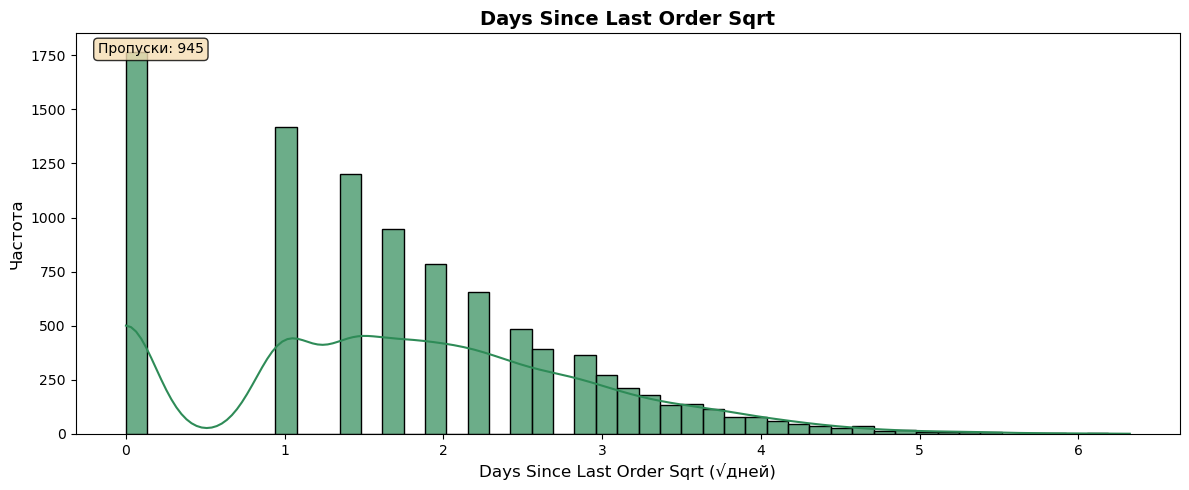

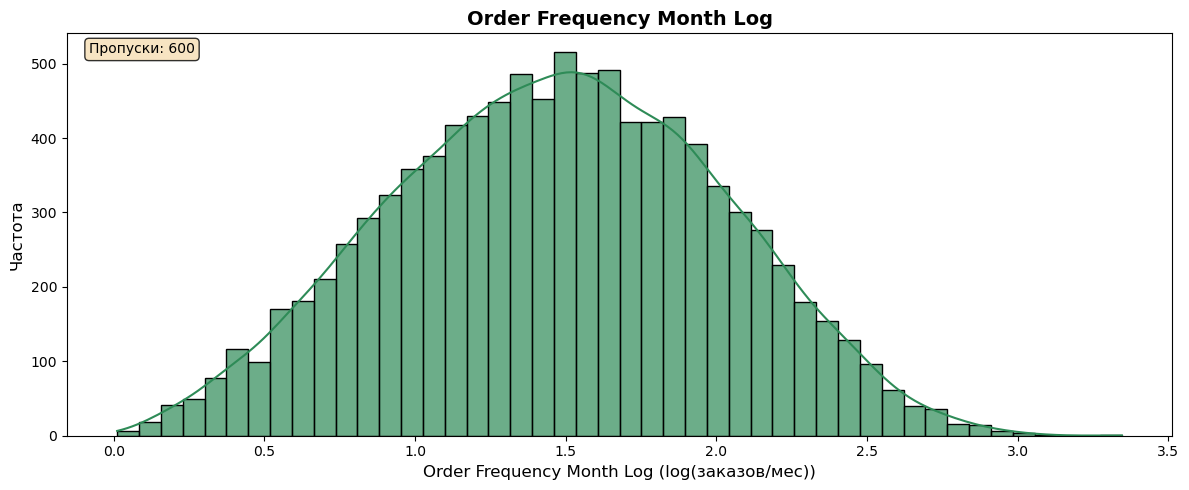

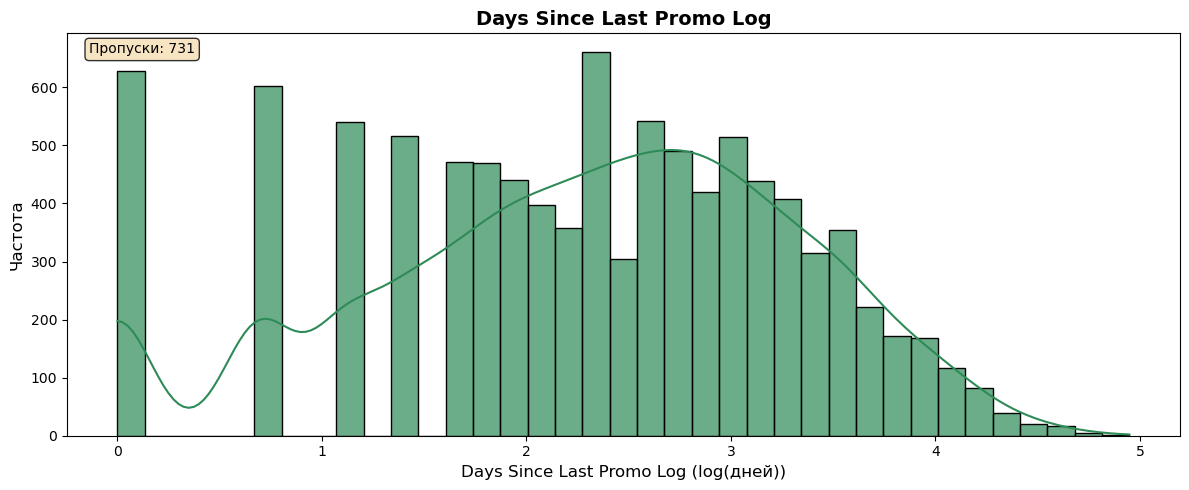

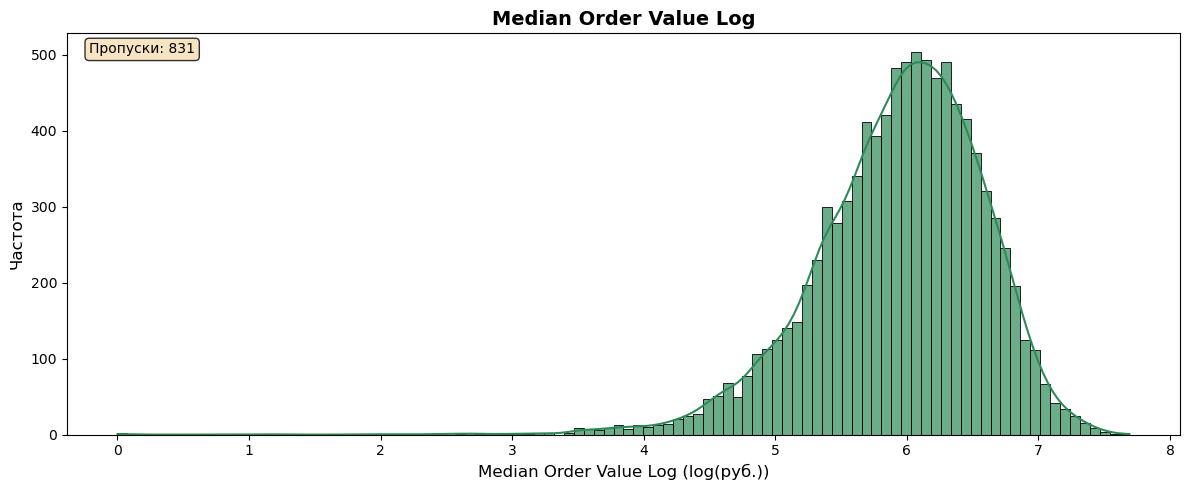

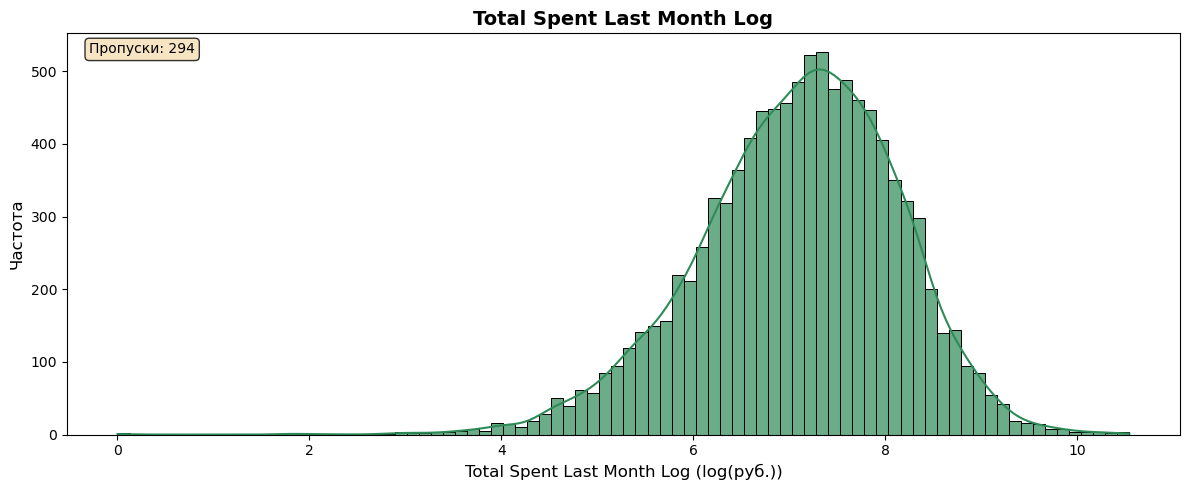

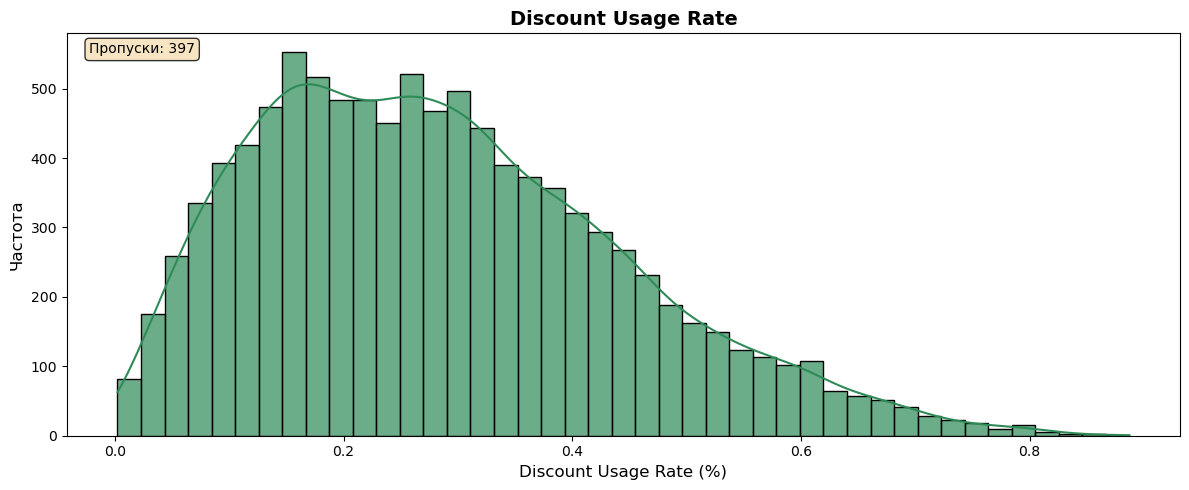

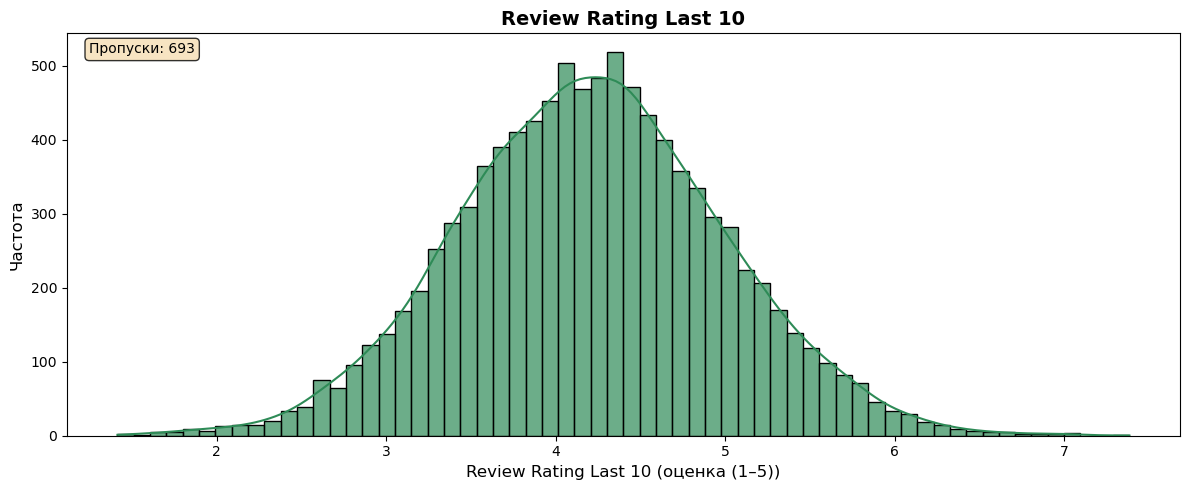

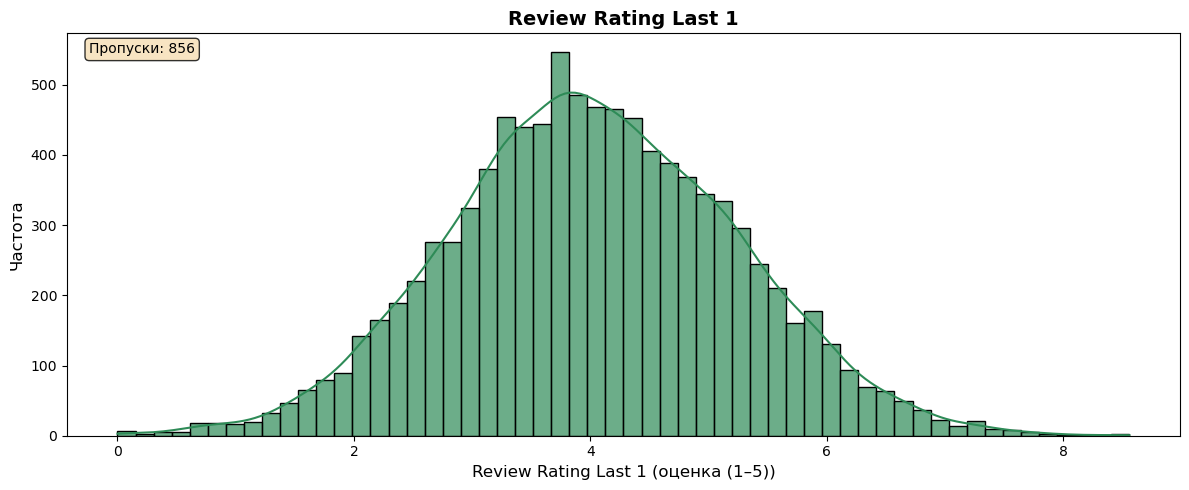

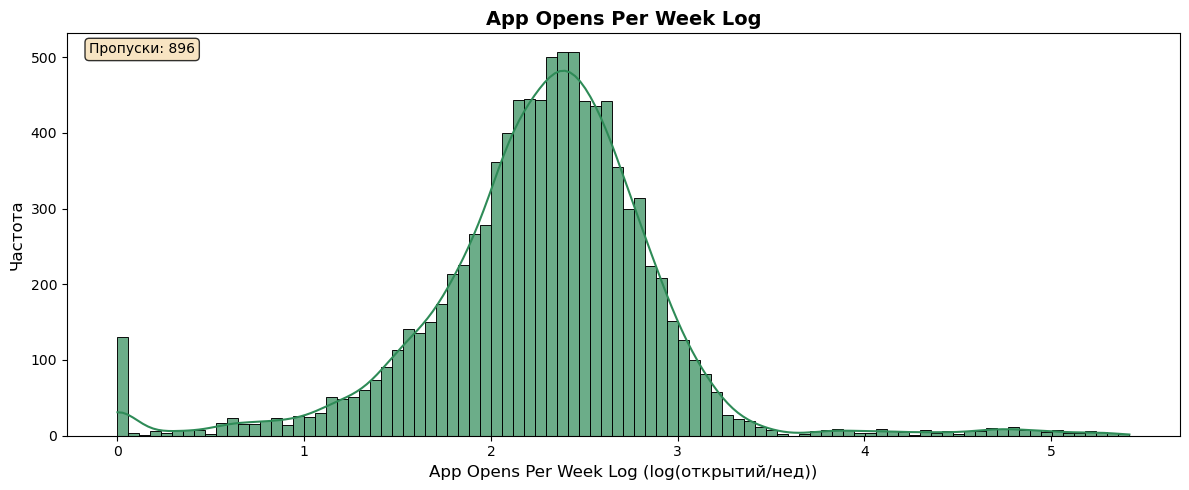

In [30]:
features_enhanced = ['days_since_last_order_sqrt', 'order_frequency_month_log', 'days_since_last_promo_log',
                   'median_order_value_log', 'total_spent_last_month_log',
                   'discount_usage_rate', 'review_rating_last_10', 'review_rating_last_1',
                   'app_opens_per_week_log']

# Словарь с единицами измерения для каждого признака
units_of_measurement = {
    'days_since_last_order_sqrt': '√дней',
    'order_frequency_month_log': 'log(заказов/мес)',
    'days_since_last_promo_log': 'log(дней)',
    'median_order_value_log': 'log(руб.)',
    'total_spent_last_month_log': 'log(руб.)',
    'discount_usage_rate': '%',
    'review_rating_last_10': 'оценка (1–5)',
    'review_rating_last_1': 'оценка (1–5)',
    'app_opens_per_week_log': 'log(открытий/нед)'
}

print("АНАЛИЗ ПРЕОБРАЗОВАННЫХ ПРИЗНАКОВ — ГИСТОГРАММЫ")
print("=" * 60)

for feature in features_enhanced:
    # Создаём отдельную фигуру для каждой гистограммы
    fig, ax = plt.subplots(figsize=(12, 5))
    
    # Гистограмма с KDE
    sns.histplot(data=data_enhanced, x=feature, kde=True, ax=ax, color='#2E8B57', alpha=0.7)
    ax.set_title(feature.replace('_', ' ').title(), fontweight='bold', fontsize=14)
    
    # Подписываем ось X с единицами измерения
    unit = units_of_measurement.get(feature, '')
    if unit:
        ax.set_xlabel(f'{feature.replace("_", " ").title()} ({unit})', fontsize=12)
    else:
        ax.set_xlabel(feature.replace('_', ' ').title(), fontsize=12)
    ax.set_ylabel('Частота', fontsize=12)
    
    # Если признак содержит пропуски, указываем их количество в заголовке
    n_missing = data_enhanced[feature].isnull().sum()
    if n_missing > 0:
        ax.text(0.02, 0.95, f'Пропуски: {n_missing}', transform=ax.transAxes,
                fontsize=10, bbox=dict(boxstyle='round', facecolor="wheat", alpha=0.8))
    
    plt.tight_layout()
    plt.show()


Распределение числовых значений стало более симметричным

In [31]:
num_features_enhanced = ['days_since_last_order_sqrt', 'order_frequency_month_log', 'days_since_last_promo_log', 'median_order_value_log', 'total_spent_last_month_log', 
           'discount_usage_rate', 'review_rating_last_10', 'review_rating_last_1', 'app_crashes_last_month_squared', 'app_opens_per_week_log']

# Обновляем трансформер
preprocessor_enhanced = ColumnTransformer(
    transformers = [
        ('num_new', num_pipeline, num_features_enhanced),
        ('cat_new', cat_pipeline, cat_features)
    ]
)

# Формируем обновленный пайплайн основной модели
advanced_pipeline = Pipeline(steps = [
    ('feature_engineering', FunctionTransformer(create_enhanced_features, validate=False)),
    ('preprocessor', preprocessor_enhanced),
    ('model', LogisticRegression(random_state=RANDOM_STATE, max_iter=2000))
])

# Выполняем кросс-валидацию основной модели на обновленных данных

cv_results_log_enhanced = cross_validate(
    estimator=advanced_pipeline,
    X = X_train_val,
    y = y_train_val,
    scoring = scoring,
    cv = kfold
)
log_means_enhanced = {
    'log_loss' : round (np.mean (- cv_results_log_enhanced ['test_neg_log_loss']), 3),
    'pr_auc' : round (np.mean (cv_results_log_enhanced ['test_average_precision']), 3)    
}
print("Результаты обновленной модели (средние значения):")
print("-" * 50)
print(f"Log Loss: {log_means_enhanced['log_loss']}")
print(f"PR-AUC:   {log_means_enhanced['pr_auc']}\n")

# Сравнение моделей
print("\nСравнение моделей:")
print("-" * 50)
print(f"{'Метрика':<12} {'Базовая':<12} {'Основная':<12} {'Улучшенная':<12} {'Изменение':<10}")
print("-" * 50)

for metric in ["log_loss", "pr_auc"]:
    # Получаем значения для каждой модели
    base_val = base_means[metric]
    log_val = log_means[metric]
    log_enhanced_val = log_means_enhanced[metric]  
    
    # Для log_loss уменьшение означает улучшение
    if metric == "log_loss":
        # Сравниваем улучшенную с основной
        change = log_val - log_enhanced_val  # Положительное значение = улучшение
        change_str = f"{change:+.3f}"
    else:  # Для PR-AUC увеличение означает улучшение
        change = log_enhanced_val - log_val  # Положительное значение = улучшение
        change_str = f"{change:+.3f}"
    
    print(
        f"{metric.upper():<12} {base_val:<12.3f} {log_val:<12.3f} {log_enhanced_val:<12.3f} {change_str:<10}"
    )

Результаты обновленной модели (средние значения):
--------------------------------------------------
Log Loss: 0.117
PR-AUC:   0.682


Сравнение моделей:
--------------------------------------------------
Метрика      Базовая      Основная     Улучшенная   Изменение 
--------------------------------------------------
LOG_LOSS     0.227        0.126        0.117        +0.009    
PR_AUC       0.060        0.646        0.682        +0.036    


**Вывод по результатам моделей**  
Проведённый эксперимент показал существенное улучшение качества модели после проведённых оптимизаций. 

Анализ изменений по метрикам  
**Log Loss (логарифмическая потеря)**

- Базовая модель: 0.227.

- Улучшенная модель: 0.117.

- Общее улучшение: −0.110 (−48 %) относительно базовой модели.

- Дополнительный прирост от последней оптимизации: −0.008 (−6.4 %) относительно основной модели.

 Cнижение Log Loss означает, что предсказания вероятностей стали более точными и уверенными. Модель реже выдаёт ошибочные высокие вероятности для неверных классов.

**PR‑AUC (площадь под кривой Precision‑Recall)**

- Базовая модель: 0.060.

- Улучшенная модель: 0.682.

- Общее улучшение: +0.622 (+913 %) относительно базовой модели.

- Дополнительный прирост: +0.036 (+5.6 %) относительно основной модели.

Резкий рост PR‑AUC говорит о значительном улучшении способности модели разделять классы, особенно в условиях дисбаланса. Повысились точность (Precision) и полнота (Recall) на разных порогах классификации.

Изучим влияние весов коэффициентов. Исключим из данных признак геолокации. 

In [32]:
from scipy import stats
# Обучаем модель
model = advanced_pipeline
model.fit(X_train_val, y_train_val)

# Получаем названия признаков (с проверкой на случай ошибки)
try:
    feature_names = advanced_pipeline.named_steps['preprocessor'].get_feature_names_out()
except AttributeError:
    feature_names = X_train_val.columns.tolist()

# Фильтруем признаки: убираем всё, что содержит 'geo_location'
filtered_features = [f for f in feature_names if 'geo_location' not in f]


# Веса логистической регрессии
coefs = model.named_steps['model'].coef_[0]

# Оставляем только коэффициенты для отфильтрованных признаков
# (предполагаем, что порядок коэффициентов соответствует порядку признаков)
if len(filtered_features) < len(coefs):
    # Находим индексы отфильтрованных признаков в исходном списке
    filtered_indices = [i for i, f in enumerate(feature_names) if 'geo_location' not in f]
    coefs_filtered = coefs[filtered_indices]
else:
    coefs_filtered = coefs

# Расчёт p‑значений для оценки значимости
std_error = np.std(coefs_filtered) / np.sqrt(len(coefs_filtered))
z_scores = coefs_filtered / std_error
p_values = 2 * (1 - stats.norm.cdf(np.abs(z_scores)))

# Создаём DataFrame и добавляем полезные столбцы
coef_df = pd.DataFrame({
    "Признак": filtered_features,
    "Коэффициент": coefs_filtered,
    "Модуль коэф.": np.abs(coefs_filtered),
    "Отношение шансов": np.exp(coefs_filtered),
    "P‑значение": p_values,
    "Значимый (p<0.05)": p_values < 0.05
})

# Сортируем по модулю коэффициента (от большего к меньшему)
coef_df_sorted = coef_df.sort_values(by="Модуль коэф.", ascending=False).reset_index(drop=True)

# Выводим заголовок и топ‑10 признаков
print("АНАЛИЗ ВЕСОВ ЛОГИСТИЧЕСКОЙ РЕГРЕССИИ (без признаков geo_location)")
print("=" * 80)
print(f"Всего признаков (без geo_location): {len(coef_df_sorted)}")
print(f"Значимых (p < 0.05): {coef_df_sorted['Значимый (p<0.05)'].sum()}")
print("\nТОП‑10 ПРИЗНАКОВ ПО СИЛЕ ВЛИЯНИЯ:")
print("-" * 80)
print(coef_df_sorted[["Признак", "Коэффициент", "Отношение шансов", "P‑значение", "Значимый (p<0.05)"]].head(10).to_string(index=False))

# Дополнительно: самые сильные положительный и отрицательный признаки
top_positive = coef_df_sorted[coef_df_sorted["Коэффициент"] > 0].iloc[0]
top_negative = coef_df_sorted[coef_df_sorted["Коэффициент"] < 0].iloc[0]

print("\nСАМЫЕ СИЛЬНЫЕ ПРИЗНАКИ:")
print("-" * 40)
print(f"Положительный: {top_positive['Признак']} (коэф. = {top_positive['Коэффициент']:.3f})")
print(f"Отрицательный: {top_negative['Признак']} (коэф. = {top_negative['Коэффициент']:.3f})")


АНАЛИЗ ВЕСОВ ЛОГИСТИЧЕСКОЙ РЕГРЕССИИ (без признаков geo_location)
Всего признаков (без geo_location): 50
Значимых (p < 0.05): 38

ТОП‑10 ПРИЗНАКОВ ПО СИЛЕ ВЛИЯНИЯ:
--------------------------------------------------------------------------------
                                Признак  Коэффициент  Отношение шансов   P‑значение  Значимый (p<0.05)
num_new__app_crashes_last_month_squared     1.838616          6.287830 0.000000e+00               True
        num_new__app_opens_per_week_log     0.829367          2.291868 0.000000e+00               True
     num_new__order_frequency_month_log     0.709673          2.033327 0.000000e+00               True
      cat_new__last_coffee_type_arabica    -0.527997          0.589785 0.000000e+00               True
     cat_new__subscription_status_basic    -0.519365          0.594898 0.000000e+00               True
    num_new__total_spent_last_month_log    -0.508604          0.601334 0.000000e+00               True
       cat_new__preferred_roast_mi

В полне логичный результат, чем чаще у пользователя случается вылет из приложения, тем больше вероятность его ухода.

## Эксперименты с гиперпараметрами

In [33]:
# Список значений C для проверки
C_values = [0.001, 0.01, 0.1, 1, 10, 100]

# Словарь для хранения результатов
results = []


print("ПЕРЕБОР ГИПЕРПАРАМЕТРОВ C ДЛЯ ЛОГИСТИЧЕСКОЙ РЕГРЕССИИ")
print("=" * 50)

for c in C_values:
    print(f"\nОбработка C = {c}...")
    
    # Создаём пайплайн с текущей конфигурацией
    pipeline_exp = Pipeline(steps=[
        ('feature_engineering', FunctionTransformer(create_enhanced_features, validate=False)),
        ('preprocessor', preprocessor_enhanced),
        ('model', LogisticRegression(
            C=c,
            random_state=RANDOM_STATE,
            max_iter=1000,  
            solver='liblinear'  
        ))
    ])
    
    try:
        # Кросс‑валидация с обработкой ошибок
        cv_results_exp = cross_validate(
            estimator=pipeline_exp,
            X=X_train_val,
            y=y_train_val,
            scoring=scoring,
            cv=kfold,
            error_score=np.nan 
        )
        
        
        if np.any(np.isnan(cv_results_exp['test_neg_log_loss'])):
            print(f"  Предупреждение: ошибки в кросс‑валидации для C={c}")
            continue
        
        # Расчёт метрик с обработкой возможных ошибок
        log_loss_mean = round(np.mean(-cv_results_exp['test_neg_log_loss']), 3)
        pr_auc_mean = round(np.mean(cv_results_exp['test_average_precision']), 3)
        
        # Сохранение результатов
        results.append({
            'C': c,
            'Log Loss': log_loss_mean,
            'PR-AUC': pr_auc_mean,
            'std_log_loss': round(np.std(-cv_results_exp['test_neg_log_loss']), 4),
            'std_pr_auc': round(np.std(cv_results_exp['test_average_precision']), 4)
        })
        
        # Вывод результатов для текущего C
        print(f"  Результаты для C = {c}:")
        print(f"    Log Loss: {log_loss_mean} (std: {round(np.std(-cv_results_exp['test_neg_log_loss']), 4)})")
        print(f"    PR-AUC:  {pr_auc_mean} (std: {round(np.std(cv_results_exp['test_average_precision']), 4)})")
        
    except Exception as e:
        print(f"  Ошибка при обработке C={c}: {str(e)}")
        continue

# Создаём DataFrame с результатами для удобного анализа
if results:
    results_df = pd.DataFrame(results)
    
    # Сортируем по PR‑AUC (лучший результат сверху)
    best_result = results_df.sort_values(by='PR-AUC', ascending=False).iloc[0]
    
    
    
    print("\nПОЛНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ:")
    print("=" * 50)
    print(results_df.to_string(index=False))
else:
    print("\nНе удалось получить валидные результаты кросс‑валидации.")


ПЕРЕБОР ГИПЕРПАРАМЕТРОВ C ДЛЯ ЛОГИСТИЧЕСКОЙ РЕГРЕССИИ

Обработка C = 0.001...
  Результаты для C = 0.001:
    Log Loss: 0.206 (std: 0.0035)
    PR-AUC:  0.672 (std: 0.0534)

Обработка C = 0.01...
  Результаты для C = 0.01:
    Log Loss: 0.125 (std: 0.0067)
    PR-AUC:  0.694 (std: 0.0501)

Обработка C = 0.1...
  Результаты для C = 0.1:
    Log Loss: 0.114 (std: 0.009)
    PR-AUC:  0.694 (std: 0.0499)

Обработка C = 1...
  Результаты для C = 1:
    Log Loss: 0.117 (std: 0.0105)
    PR-AUC:  0.682 (std: 0.052)

Обработка C = 10...
  Результаты для C = 10:
    Log Loss: 0.124 (std: 0.0119)
    PR-AUC:  0.663 (std: 0.0545)

Обработка C = 100...
  Результаты для C = 100:
    Log Loss: 0.131 (std: 0.0127)
    PR-AUC:  0.649 (std: 0.0573)

ПОЛНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ:
      C  Log Loss  PR-AUC  std_log_loss  std_pr_auc
  0.001     0.206   0.672        0.0035      0.0534
  0.010     0.125   0.694        0.0067      0.0501
  0.100     0.114   0.694        0.0090      0.0499
  1.000     0.117   0

Оптимальный выбор — C = 0.1, потому что:

- даёт максимальный Log Loss (0.114) среди всех вариантов;

- имеет наименьшие стандартные отклонения по метрикам (наибольшая стабильность);

- показывает лучший баланс между сложностью модели и обобщающей способностью;

- PR‑AUC такой же, как у C = 0.01, но с лучшей стабильностью.

## Подготовка финальной модели

ОБУЧЕНИЕ ФИНАЛЬНОЙ МОДЕЛИ
Обучение модели на X_train_val...
Модель успешно обучена!

Получение предсказаний на тестовой выборке...

Расчёт финальных метрик...

ФИНАЛЬНЫЕ РЕЗУЛЬТАТЫ НА ТЕСТОВОЙ ВЫБОРКЕ:
Log Loss: 0.1068
PR-AUC:   0.7346

ДЕТАЛЬНАЯ ОЦЕНКА МОДЕЛИ:
Матрица ошибок:
[[1951   13]
 [  58   68]]

Отчёт по классификации:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1964
           1       0.84      0.54      0.66       126

    accuracy                           0.97      2090
   macro avg       0.91      0.77      0.82      2090
weighted avg       0.96      0.97      0.96      2090


СРАВНЕНИЕ С РЕЗУЛЬТАТАМИ КРОСС‑ВАЛИДАЦИИ:
Метрика      CV (среднее)    Test            Разница      Статус    
------------------------------------------------------------
LOG_LOSS     0.1310          0.1068          -0.0242 Улучшение 
PR_AUC       0.6490          0.7346          +0.0856 Улучшение 

ТАБЛИЦА СРАВНЕНИЯ (DataFrame):
 Метрика C

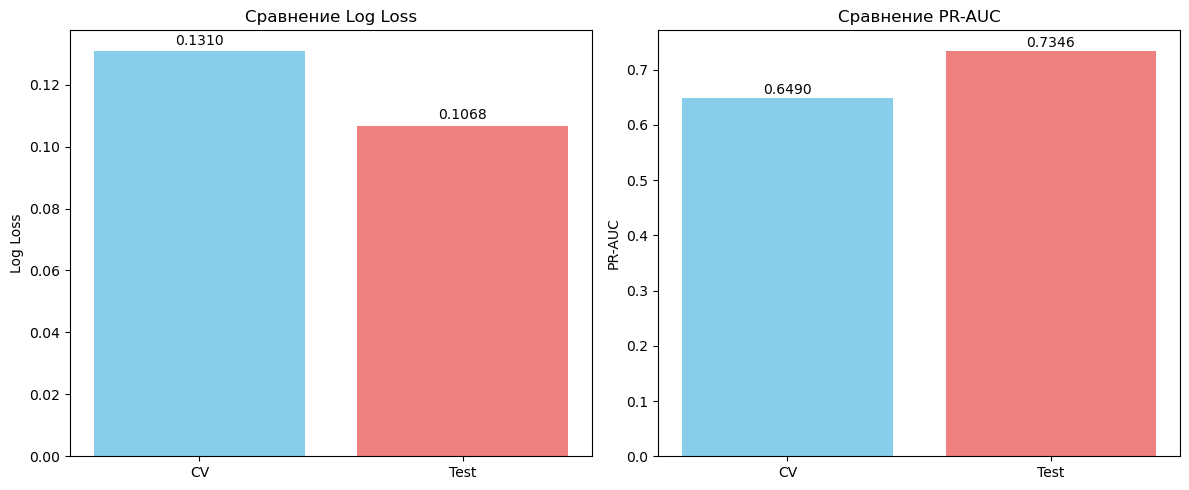


АНАЛИЗ КАЛИБРОВКИ ВЕРОЯТНОСТЕЙ:


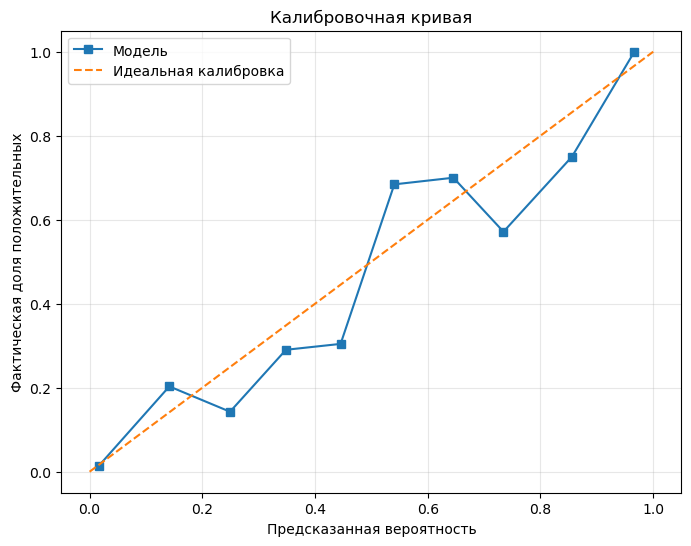


ИТОГОВЫЙ ОТЧЁТ:
final_log_loss: 0.1068
final_pr_auc: 0.7346
cv_log_loss_mean: 0.1310
cv_pr_auc_mean: 0.6490
model_parameters:
  C: 0.1
  solver: liblinear
  max_iter: 1000


In [34]:

log_means_exp_up = {
    'log_loss': log_loss_mean,
    'pr_auc': pr_auc_mean
}
# Создаём финальный пайплайн с оптимальными параметрами
final_pipeline = Pipeline(steps=[
    ('feature_engineering', FunctionTransformer(create_enhanced_features, validate=False)),
    ('preprocessor', preprocessor_enhanced),
    ('model', LogisticRegression(
        C=0.1,  # Оптимальное значение, выбранное по результатам анализа
        random_state=RANDOM_STATE,
        max_iter=1000,
        solver='liblinear'
    ))
])

print("ОБУЧЕНИЕ ФИНАЛЬНОЙ МОДЕЛИ")
print("=" * 50)

# Обучаем модель на тренировочных данных
print("Обучение модели на X_train_val...")
final_pipeline.fit(X_train_val, y_train_val)
print("Модель успешно обучена!")

# Получаем предсказания на тестовой выборке
print("\nПолучение предсказаний на тестовой выборке...")
y_test_pred_proba = final_pipeline.predict_proba(X_test)[:, 1]  # вероятности положительного класса
y_test_pred = final_pipeline.predict(X_test)  # предсказанные классы

# Рассчитываем финальные метрики
print("\nРасчёт финальных метрик...")
final_log_loss = log_loss(y_test, y_test_pred_proba)
final_pr_auc = average_precision_score(y_test, y_test_pred_proba)

print("\nФИНАЛЬНЫЕ РЕЗУЛЬТАТЫ НА ТЕСТОВОЙ ВЫБОРКЕ:")
print("=" * 50)
print(f"Log Loss: {final_log_loss:.4f}")
print(f"PR-AUC:   {final_pr_auc:.4f}")

# Детальная оценка модели
print("\nДЕТАЛЬНАЯ ОЦЕНКА МОДЕЛИ:")
print("=" * 50)
print("Матрица ошибок:")
cm = confusion_matrix(y_test, y_test_pred)
print(cm)

print("\nОтчёт по классификации:")
print(classification_report(y_test, y_test_pred))

# Сравнение с результатами кросс‑валидации
print("\nСРАВНЕНИЕ С РЕЗУЛЬТАТАМИ КРОСС‑ВАЛИДАЦИИ:")
print("=" * 60)
print(f"{'Метрика':<12} {'CV (среднее)':<15} {'Test':<15} {'Разница':<12} {'Статус':<10}")
print("-" * 60)

test_results_final = {"log_loss": final_log_loss, "pr_auc": final_pr_auc}
comparison_data = []

for metric in ["log_loss", "pr_auc"]:
    cv_mean = log_means_exp_up[metric]
    test_score = test_results_final[metric]
    diff = test_score - cv_mean

    # Определяем статус сравнения
    if metric == "log_loss":
        status = "Улучшение" if diff < 0 else "Ухудшение"
    else:  # pr_auc
        status = "Улучшение" if diff > 0 else "Ухудшение"

    comparison_data.append({
        'Метрика': metric.upper(),
        'CV (среднее)': f"{cv_mean:.4f}",
        'Test': f"{test_score:.4f}",
        'Разница': f"{diff:+.4f}",
        'Статус': status
    })

    print(f"{metric.upper():<12} {cv_mean:<15.4f} {test_score:<15.4f} {diff:+.4f} {status:<10}")

# Создаём DataFrame для удобного анализа сравнения
comparison_df = pd.DataFrame(comparison_data)
print("\nТАБЛИЦА СРАВНЕНИЯ (DataFrame):")
print(comparison_df.to_string(index=False))

# Визуализация сравнения метрик
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

metrics = ['Log Loss', 'PR-AUC']
cv_scores = [log_means_exp_up['log_loss'], log_means_exp_up['pr_auc']]
test_scores = [final_log_loss, final_pr_auc]

# График Log Loss
ax1.bar(['CV', 'Test'], [cv_scores[0], test_scores[0]], color=['skyblue', 'lightcoral'])
ax1.set_title('Сравнение Log Loss')
ax1.set_ylabel('Log Loss')

# Добавляем значения на столбцы
ax1.text(0, cv_scores[0] + 0.001, f"{cv_scores[0]:.4f}", ha='center', va='bottom')
ax1.text(1, test_scores[0] + 0.001, f"{test_scores[0]:.4f}", ha='center', va='bottom')

# График PR-AUC
ax2.bar(['CV', 'Test'], [cv_scores[1], test_scores[1]], color=['skyblue', 'lightcoral'])
ax2.set_title('Сравнение PR-AUC')
ax2.set_ylabel('PR-AUC')

# Добавляем значения на столбцы
ax2.text(0, cv_scores[1] + 0.001, f"{cv_scores[1]:.4f}", ha='center', va='bottom')
ax2.text(1, test_scores[1] + 0.001, f"{test_scores[1]:.4f}", ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Анализ калибровки вероятностей
print("\nАНАЛИЗ КАЛИБРОВКИ ВЕРОЯТНОСТЕЙ:")
print("=" * 50)
from sklearn.calibration import calibration_curve

fraction_pos, mean_pred = calibration_curve(y_test, y_test_pred_proba, n_bins=10)

plt.figure(figsize=(8, 6))
plt.plot(mean_pred, fraction_pos, "s-", label="Модель")
plt.plot([0, 1], [0, 1], "--", label="Идеальная калибровка")
plt.xlabel("Предсказанная вероятность")
plt.ylabel("Фактическая доля положительных")
plt.title("Калибровочная кривая")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Сохранение важных результатов
results_summary = {
    'final_log_loss': final_log_loss,
    'final_pr_auc': final_pr_auc,
    'cv_log_loss_mean': log_means_exp_up['log_loss'],
    'cv_pr_auc_mean': log_means_exp_up['pr_auc'],
    'model_parameters': {
        'C': 0.1,
        'solver': 'liblinear',
        'max_iter': 1000
    }
}

print("\nИТОГОВЫЙ ОТЧЁТ:")
print("=" * 50)
for key, value in results_summary.items():
    if isinstance(value, dict):
        print(f"{key}:")
        for k, v in value.items():
            print(f"  {k}: {v}")
    else:
        print(f"{key}: {value:.4f}" if isinstance(value, float) else f"{key}: {value}")

## Отчёт о проделанной работе

В ходе исследования была построена и оценена модель логистической регрессии для решения задачи бинарной классификации. 
Разберём ключевые этапы и итоги.

**1. Подготовительный этап**  
Предобработка данных:

- Данные исследованы на наличие дубликатов, пропущенных значений и аномалий.
- Построена матрица корреляций, исследованы признаки и их влияние на целевую переменную.
- Реализованы пайплайны для обработки пропущенных значений, масштабирования числовых и кодирования категориальных признаков.
- Проведена кросс-валидация на базовой модели, изучены метрики. 
- Создание признаков: применены преобразования для улучшения качества модели.

**2. Подбор гиперпараметров**  
После преобразования признаков, цикл повторили на измененном датасете.
Выполнен перебор значений параметра регуляризации C ([0.001, 0.01, 0.1, 1, 10, 100]) с оценкой по кросс‑валидации.

Ключевые результаты:

- Лучший PR‑AUC (0.694) достигнут при C = 0.01 и C = 0.1.

- Лучший Log Loss (0.114) — при C = 0.1, с наименьшими стандартными отклонениями (наибольшая стабильность).

- При малых C (0.001) — недообучение (Log Loss = 0.206).

- При больших C (≥ 10) — признаки переобучения (рост Log Loss, падение PR‑AUC).

- Выбранный параметр: C = 0.1 как оптимальный баланс между сложностью модели и обобщающей способностью.

**3. Обучение финальной модели**
Модель обучена на тренировочной выборке (X_train_val, y_train_val) с параметрами:

- C = 0.1;

- solver = 'liblinear';

- max_iter = 1000.

**4. Оценка на тестовой выборке**
Основные метрики:

- Log Loss: 0.1068 (улучшение на 0.0242 относительно CV);

- PR‑AUC: 0.7346 (улучшение на 0.0856 относительно CV).

Модель готова к применению на практике.

## Сохранение модели для продакшена

In [35]:
# Сохраняем финальный пайплайн (включает предобработку и модель)
model_filename = 'final_logistic_regression_pipeline.pkl'
joblib.dump(final_pipeline, model_filename)


print(f"Финальный пайплайн успешно сохранён в файл: {model_filename}")


Финальный пайплайн успешно сохранён в файл: final_logistic_regression_pipeline.pkl


In [36]:
# Загружаем пайплайн из файла
loaded_pipeline = joblib.load(model_filename)
print("Финальный пайплайн успешно загружен из файла!")

# Проверяем, что загруженная модель идентична исходной
print("\nПроверка идентичности моделей:")
print(f"Тип пайплайна: {type(loaded_pipeline)}")
print(f"Шаги пайплайна: {[step[0] for step in loaded_pipeline.steps]}")

# Получаем параметры модели для проверки
model_params = loaded_pipeline.named_steps['model'].get_params()
print(f"\nПараметры модели после загрузки:")
print(f"C: {model_params['C']}")
print(f"solver: {model_params['solver']}")
print(f"random_state: {model_params['random_state']}")



Финальный пайплайн успешно загружен из файла!

Проверка идентичности моделей:
Тип пайплайна: <class 'sklearn.pipeline.Pipeline'>
Шаги пайплайна: ['feature_engineering', 'preprocessor', 'model']

Параметры модели после загрузки:
C: 0.1
solver: liblinear
random_state: 42


In [37]:
print("\n" + "="*50)
print("ПРОВЕРКА ЗАГРУЖЕННОЙ МОДЕЛИ НА ТЕСТОВЫХ ДАННЫХ")
print("="*50)

# Предсказания с загруженной моделью
y_test_pred_proba_loaded = loaded_pipeline.predict_proba(X_test)[:, 1]
y_test_pred_loaded = loaded_pipeline.predict(X_test)

# Рассчитываем метрики для загруженной модели


loaded_log_loss = log_loss(y_test, y_test_pred_proba_loaded)
loaded_pr_auc = average_precision_score(y_test, y_test_pred_proba_loaded)

print("РЕЗУЛЬТАТЫ ЗАГРУЖЕННОЙ МОДЕЛИ:")
print(f"Log Loss: {loaded_log_loss:.4f}")
print(f"PR-AUC:   {loaded_pr_auc:.4f}")

# Сравниваем с результатами исходной модели
print("\nСРАВНЕНИЕ С ИСХОДНОЙ МОДЕЛЬЮ:")
print("-"*40)
print(f"{'Метрика':<12} {'Исходная':<12} {'Загруженная':<12} {'Разница':<10}")
print("-"*40)

metrics_comparison = {
    'log_loss': (final_log_loss, loaded_log_loss),
    'pr_auc': (final_pr_auc, loaded_pr_auc)
}

for metric, (original, loaded) in metrics_comparison.items():
    diff = abs(original - loaded)
    status = "OK" if diff < 1e-10 else "РАЗЛИЧИЕ!"
    print(f"{metric.upper():<12} {original:<12.4f} {loaded:<12.4f} {diff:<10.8f} {status}")



ПРОВЕРКА ЗАГРУЖЕННОЙ МОДЕЛИ НА ТЕСТОВЫХ ДАННЫХ
РЕЗУЛЬТАТЫ ЗАГРУЖЕННОЙ МОДЕЛИ:
Log Loss: 0.1068
PR-AUC:   0.7346

СРАВНЕНИЕ С ИСХОДНОЙ МОДЕЛЬЮ:
----------------------------------------
Метрика      Исходная     Загруженная  Разница   
----------------------------------------
LOG_LOSS     0.1068       0.1068       0.00000000 OK
PR_AUC       0.7346       0.7346       0.00000000 OK


In [38]:
import json
from datetime import datetime

model_metadata = {
    "model_name": "LogisticRegression_Pipeline",
    "creation_date": datetime.now().isoformat(),
    "version": "1.0",
    "hyperparameters": {
        "C": 0.1,
        "solver": "liblinear",
        "max_iter": 1000,
        "random_state": RANDOM_STATE
    },
    "performance_metrics": {
        "test_log_loss": final_log_loss,
        "test_pr_auc": final_pr_auc
    },
    "feature_engineering": "create_enhanced_features function",
    "preprocessor": "preprocessor_enhanced",
    "training_data_shape": X_train_val.shape,
    "test_data_shape": X_test.shape
}

# Сохраняем метаданные
metadata_filename = 'model_metadata.json'
with open(metadata_filename, 'w', encoding='utf-8') as f:
    json.dump(model_metadata, f, indent=2, ensure_ascii=False)

print(f"\nМетаданные модели сохранены в файл: {metadata_filename}")



Метаданные модели сохранены в файл: model_metadata.json
